# Predicting Sales from Campaign Data

## Executive Summary

This case study predicts campaign sales before launch using follower count,
planned ad spend, historical engagement, and pre-launch content quality. A
temporally selected Lasso model achieved RMSE of 1,956 units, MAE of 1,564 units,
and R² of 0.504 on the latest-20% holdout. Approximately 72% of temporal
predictions were within ±20% of actual sales. Followers and planned ad spend
were the strongest predictive feature families. Results depend on confirming
feature availability and the follower-unit assumption with the data owner.

## Business Context

Marketing teams often invest heavily in influencer campaigns, but they need a reliable way to estimate how many product units a campaign is likely to sell before making budget and creator decisions.

This case study builds an end-to-end regression workflow to predict **Sales (Units)** from influencer campaign attributes such as followers, engagement rate, planned ad spend, and a pre-launch content-quality assessment. The observed campaign-end timestamp and Notes are retained for auditing and validation design but excluded from prediction.

## Case Study Objectives

- Clean messy campaign data with missing values, mixed formats, and outliers.
- Explore and visualize relationships between campaign features and sales.
- Engineer stronger model features such as log transforms and interaction terms.
- Train and compare regression models.
- Use cross-validation and hyperparameter tuning.
- Evaluate using RMSE, MAE, and R².
- Explain which factors matter most for sales.
- Create a simple reusable prediction function for future messy campaign data.

## Prediction Timing and Feature Availability

**Prediction point:** before campaign launch, when the marketing team is deciding
whether to approve a proposed campaign. The model estimates eventual units sold
using only fields assumed to be available at that decision point.

| Field | Expected availability | Production-model treatment |
|---|---|---|
| `Followers` | Before launch | Included as the follower count observed at planning time |
| `AdSpend (GBP)` | Before launch only if it represents the planned budget | Included under the documented planned-spend assumption |
| `EngagementRate (%)` | Requires clarification | Included only under the assumption that it is historical influencer engagement; campaign-post engagement would be leakage |
| `ContentQuality` | Requires clarification | Included only if scored from proposed content or prior creator content before approval |
| `Timestamp` | The supplied field is the observed campaign-end date | Excluded from prediction; retained for chronological validation and audit |
| `Notes` | Potentially recorded during or after campaign completion | Excluded from prediction; retained for descriptive analysis |
| `Sales (Units)` | Known after completion | Prediction target |
| `ID` | Available before launch | Retained for joining predictions, not used as a predictive signal |

The data owner should confirm the definitions of engagement, spend, and content
quality before production deployment. If they are realized campaign outcomes rather
than planning-time values, they must also be removed or replaced with historical or
planned equivalents.

## Step 1 - Load Libraries and Dataset

**Goal:** Load the training and testing datasets and confirm the target variable.

In [1]:
from pathlib import Path
import json
import math
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, TimeSeriesSplit, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
plt.style.use("default")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

BASE_DIR = Path.cwd()
if not (BASE_DIR / "messy_train_data.csv").exists():
    BASE_DIR = Path("Predicting Sales from Campaign Data")

TRAIN_PATH = BASE_DIR / "messy_train_data.csv"
TEST_PATH = BASE_DIR / "messy_test_data.csv"
PREDICTIONS_PATH = Path("messy_test_predictions.csv")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)
display(train.head())

Training data shape: (8000, 8)
Testing data shape: (2000, 7)


,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes
0,"106,572.000",2.573174871146172,2614.3781948587675,5.276,6340,9254,2021-11-27,Pending
1,"77,583.000",0.9394984315675532,4975.962514379572,8.756,5793,1561,2022-02-13,Review
2,"92,832.000",2.1761012652155296,4107.769534318886,6.455,8104,1670,2023-09-25,Pending
3,"53,565.000",1.4783757541486553,4293.330464613049,4.313,7293,6087,2023-02-15,Review
4,"121,079.000",3.3741976179329356,5343.549440897207,3.769,14396,6669,2023-05-28,NaN


### Conclusion - Step 1

The training dataset contains the target column `Sales (Units)`, while the testing dataset does not. Therefore, model quality will be evaluated using a holdout split and cross-validation from the training dataset. The separate test dataset will be used for final sales predictions.

## Step 2 - Understand Dataset Columns

| Column | Meaning | Modeling Treatment |
|---|---|---|
| `Followers` | Instagram follower count at campaign time | Clean numeric value, handle mixed scales, create log feature |
| `EngagementRate (%)` | Likes/comments per follower | Parse percent or numeric strings |
| `AdSpend (GBP)` | Campaign spend in GBP | Parse currency strings and handle invalid negative values |
| `ContentQuality` | Subjective content score from 1 to 10 | Validate and use as numeric input |
| `Sales (Units)` | Units sold from campaign | Target variable |
| `ID` | Campaign identifier | Used only for output joining; never passed to the model |
| `Timestamp` | Observed campaign end date | Retained for temporal validation and audit; excluded from prediction |
| `Notes` | Operational campaign note | Retained for analysis only; excluded from prediction because it may be recorded after campaign completion |

In [2]:
column_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing_values": train.isna().sum().values,
    "unique_values": train.nunique(dropna=True).values,
})
display(column_summary)

print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

duplicate_train_ids = int(train["ID"].duplicated().sum())
duplicate_test_ids = int(test["ID"].duplicated().sum())
overlapping_ids = set(train["ID"].dropna()) & set(test["ID"].dropna())

print("Duplicate train IDs:", duplicate_train_ids)
print("Duplicate test IDs:", duplicate_test_ids)
print("Train/test overlapping IDs:", len(overlapping_ids))
if overlapping_ids:
    print(
        "Caution: overlapping IDs may indicate that the same campaigns appear "
        "in both datasets and should be confirmed with the data owner."
    )
else:
    print("No campaign IDs overlap between the train and test datasets.")


,column,dtype,missing_values,unique_values
0,Followers,float64,160,7403
1,EngagementRate (%),object,160,7800
2,AdSpend (GBP),object,159,7815
3,ContentQuality,float64,160,7840
4,Sales (Units),int64,0,5582
5,ID,int64,0,8000
6,Timestamp,object,0,1000
7,Notes,object,2652,4


Duplicate rows in train: 0
Duplicate rows in test: 0
Duplicate train IDs: 0
Duplicate test IDs: 0
Train/test overlapping IDs: 0
No campaign IDs overlap between the train and test datasets.


### Conclusion - Step 2

The raw dataset includes numeric, categorical, date, and identifier columns. Several important numeric columns are stored as strings, so direct modeling would be unreliable without cleaning.

## Step 3 - Build Reusable Cleaning and Feature Engineering Code

**Goal:** Define all cleaning and feature-engineering logic inside the notebook.

In [3]:
MODEL_FEATURES = [
    "Followers",
    "EngagementRate (%)",
    "AdSpend (GBP)",
    "ContentQuality",
]

CLEANED_RAW_FEATURES = [
    "followers",
    "engagement_rate",
    "ad_spend",
    "content_quality",
]

ENGINEERED_FEATURES = [
    "log_followers",
    "log_ad_spend",
    "estimated_engaged_followers",
    "log_estimated_engaged_followers",
    "spend_per_1k_followers",
    "quality_x_engagement",
    "spend_x_quality",
    "followers_thousand_scaled_flag",
    "followers_outlier_flag",
    "engagement_invalid_flag",
    "ad_spend_invalid_flag",
    "ad_spend_outlier_flag",
    "content_quality_invalid_flag",
]

NUMERIC_FEATURES = CLEANED_RAW_FEATURES + ENGINEERED_FEATURES
PRODUCTION_NUMERIC_FEATURES = CLEANED_RAW_FEATURES

DATE_FEATURES = [
    "year",
    "month",
    "quarter",
    "dayofweek",
    "days_since_start",
    "timestamp_missing_flag",
]

CATEGORICAL_FEATURES = []


def _is_grouped_integer(text, separator):
    """Return True for grouped integers such as 1,234,567."""
    parts = text.split(separator)
    return (
        len(parts) > 1
        and 1 <= len(parts[0]) <= 3
        and parts[0].isdigit()
        and all(part.isdigit() and len(part) == 3 for part in parts[1:])
    )


def _normalise_number_separators(text):
    """Resolve common decimal and thousands separators without guessing malformed values."""
    if "," in text and "." in text:
        decimal_separator = "," if text.rfind(",") > text.rfind(".") else "."
        thousands_separator = "." if decimal_separator == "," else ","
        if text.count(decimal_separator) != 1:
            return None
        integer_part, decimal_part = text.rsplit(decimal_separator, 1)
        if not decimal_part.isdigit():
            return None
        if thousands_separator in integer_part:
            if not _is_grouped_integer(integer_part, thousands_separator):
                return None
            integer_part = integer_part.replace(thousands_separator, "")
        if not integer_part.isdigit():
            return None
        return f"{integer_part}.{decimal_part}"

    if "," in text:
        if text.count(",") == 1:
            integer_part, trailing_part = text.split(",", 1)
            if not integer_part.isdigit() or not trailing_part.isdigit():
                return None
            if len(trailing_part) == 3 and 1 <= len(integer_part) <= 3:
                return integer_part + trailing_part
            return f"{integer_part}.{trailing_part}"
        return text.replace(",", "") if _is_grouped_integer(text, ",") else None

    if text.count(".") > 1:
        return text.replace(".", "") if _is_grouped_integer(text, ".") else None
    return text


def parse_messy_number(value):
    """Parse currency, percentages, suffixes, and US/European separators safely."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        numeric_value = float(value)
        return numeric_value if np.isfinite(numeric_value) else np.nan

    text = str(value).strip()
    if not text or text.lower() in {
        "nan", "none", "null", "na", "n/a", "-", "inf", "+inf", "-inf",
        "infinity", "+infinity", "-infinity",
    }:
        return np.nan

    parenthesised_negative = text.startswith("(") and text.endswith(")")
    if parenthesised_negative:
        text = text[1:-1].strip()

    multiplier = 1.0
    suffix_match = re.search(r"([kKmMbB])\s*$", text)
    if suffix_match:
        suffix = suffix_match.group(1).lower()
        multiplier = {
            "k": 1_000.0,
            "m": 1_000_000.0,
            "b": 1_000_000_000.0,
        }[suffix]
        text = text[: suffix_match.start()]

    # Remove supported currency codes before rejecting unexpected words.
    text = re.sub(
        r"^(GBP|USD|EUR|INR)\s*",
        "",
        text,
        flags=re.IGNORECASE,
    )
    if re.search(r"[A-Za-z]", text):
        return np.nan
    text = re.sub(r"[^0-9,.+\-]", "", text)
    if not text or not re.search(r"\d", text):
        return np.nan

    sign = ""
    if text[0] in "+-":
        sign, text = text[0], text[1:]
    if not text or "+" in text or "-" in text:
        return np.nan

    normalised = _normalise_number_separators(text)
    if normalised is None:
        return np.nan

    try:
        numeric_value = float(sign + normalised) * multiplier
    except ValueError:
        return np.nan

    if parenthesised_negative:
        numeric_value = -abs(numeric_value)
    return numeric_value if np.isfinite(numeric_value) else np.nan


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


class CampaignCleaner(BaseEstimator, TransformerMixin):
    """Clean messy campaign rows and create model-ready features."""

    def __init__(
        self,
        clip_lower=0.01,
        clip_upper=0.99,
        scale_plain_small_followers=True,
        include_notes=False,
        include_timestamp=False,
    ):
        self.clip_lower = clip_lower
        self.clip_upper = clip_upper
        self.scale_plain_small_followers = scale_plain_small_followers
        self.include_notes = include_notes
        self.include_timestamp = include_timestamp

    def fit(self, X, y=None):
        cleaned = self._basic_clean(X)
        self.clip_bounds_ = {}
        for column in ["followers", "engagement_rate", "ad_spend", "content_quality"]:
            series = cleaned[column].dropna()
            if series.empty:
                self.clip_bounds_[column] = (np.nan, np.nan)
            else:
                self.clip_bounds_[column] = (
                    float(series.quantile(self.clip_lower)),
                    float(series.quantile(self.clip_upper)),
                )

        if self.include_timestamp:
            dates = pd.to_datetime(X.get("Timestamp"), errors="coerce")
            self.date_origin_ = dates.min()
            if pd.isna(self.date_origin_):
                self.date_origin_ = pd.Timestamp("2021-01-01")
        return self

    def transform(self, X):
        cleaned = self._basic_clean(X)

        for column, (lower, upper) in self.clip_bounds_.items():
            if not math.isnan(lower) and not math.isnan(upper):
                cleaned[column] = cleaned[column].clip(lower, upper)

        if self.include_timestamp:
            timestamp = pd.to_datetime(X.get("Timestamp"), errors="coerce")
            cleaned["timestamp_missing_flag"] = timestamp.isna().astype(float)
            cleaned["year"] = timestamp.dt.year.astype(float)
            cleaned["month"] = timestamp.dt.month.astype(float)
            cleaned["quarter"] = timestamp.dt.quarter.astype(float)
            cleaned["dayofweek"] = timestamp.dt.dayofweek.astype(float)
            cleaned["days_since_start"] = (
                timestamp - self.date_origin_
            ).dt.days.astype(float)

        cleaned["log_followers"] = np.log1p(cleaned["followers"])
        cleaned["log_ad_spend"] = np.log1p(cleaned["ad_spend"])
        cleaned["estimated_engaged_followers"] = cleaned["followers"] * cleaned["engagement_rate"] / 100.0
        cleaned["log_estimated_engaged_followers"] = np.log1p(cleaned["estimated_engaged_followers"])
        cleaned["spend_per_1k_followers"] = np.where(
            cleaned["followers"] > 0,
            cleaned["ad_spend"] / (cleaned["followers"] / 1000.0),
            np.nan,
        )
        cleaned["quality_x_engagement"] = cleaned["content_quality"] * cleaned["engagement_rate"]
        cleaned["spend_x_quality"] = cleaned["ad_spend"] * cleaned["content_quality"]
        cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

        output_features = list(NUMERIC_FEATURES)
        if self.include_timestamp:
            output_features.extend(DATE_FEATURES)
        if self.include_notes:
            notes = X.get("Notes")
            if notes is None:
                notes = pd.Series(index=X.index, dtype=object)
            cleaned["notes_clean"] = (
                notes.fillna("Missing")
                .astype(str)
                .str.strip()
                .replace({"": "Missing", "nan": "Missing"})
            )
            output_features.append("notes_clean")

        return cleaned[output_features]

    def _basic_clean(self, X):
        raw_followers = X.get(
            "Followers",
            pd.Series(index=X.index, dtype=object),
        )
        raw_follower_text = raw_followers.astype("string").str.strip()
        has_magnitude_suffix = raw_follower_text.str.contains(
            r"[kKmMbB]\s*$",
            regex=True,
            na=False,
        )
        is_plain_numeric_follower = raw_follower_text.str.fullmatch(
            r"[+-]?(?:\d+(?:[.,]\d+)?|[.,]\d+)",
            na=False,
        )

        followers = raw_followers.map(parse_messy_number)
        engagement = X.get("EngagementRate (%)", pd.Series(index=X.index, dtype=object)).map(parse_messy_number)
        ad_spend = X.get("AdSpend (GBP)", pd.Series(index=X.index, dtype=object)).map(parse_messy_number)
        content_quality = X.get("ContentQuality", pd.Series(index=X.index, dtype=object)).map(parse_messy_number)

        small_plain_followers = (
            followers.between(1, 999, inclusive="both")
            & is_plain_numeric_follower
            & ~has_magnitude_suffix
        )
        followers_thousand_scaled_flag = small_plain_followers.astype(float)
        if self.scale_plain_small_followers:
            followers = followers.where(~small_plain_followers, followers * 1000.0)

        followers_outlier_flag = (followers > 1_000_000).fillna(False).astype(float)
        ad_spend_outlier_flag = (ad_spend > 50_000).fillna(False).astype(float)
        engagement_invalid_flag = ((engagement <= 0) | (engagement > 100)).fillna(False).astype(float)
        ad_spend_invalid_flag = (ad_spend < 0).fillna(False).astype(float)
        content_quality_invalid_flag = ((content_quality < 1) | (content_quality > 10)).fillna(False).astype(float)

        followers = followers.mask(followers <= 0)
        engagement = engagement.mask((engagement <= 0) | (engagement > 100))
        ad_spend = ad_spend.mask(ad_spend < 0)
        content_quality = content_quality.mask((content_quality < 1) | (content_quality > 10))

        return pd.DataFrame({
            "followers": followers,
            "engagement_rate": engagement,
            "ad_spend": ad_spend,
            "content_quality": content_quality,
            "followers_thousand_scaled_flag": followers_thousand_scaled_flag,
            "followers_outlier_flag": followers_outlier_flag,
            "engagement_invalid_flag": engagement_invalid_flag,
            "ad_spend_invalid_flag": ad_spend_invalid_flag,
            "ad_spend_outlier_flag": ad_spend_outlier_flag,
            "content_quality_invalid_flag": content_quality_invalid_flag,
        }, index=X.index)


def make_preprocessor(numeric_features=None, categorical_features=None):
    numeric_features = list(
        PRODUCTION_NUMERIC_FEATURES if numeric_features is None else numeric_features
    )
    categorical_features = list(
        CATEGORICAL_FEATURES
        if categorical_features is None
        else categorical_features
    )
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    transformers = [("num", numeric_pipeline, numeric_features)]

    if categorical_features:
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_one_hot_encoder()),
        ])
        transformers.append(("cat", categorical_pipeline, categorical_features))

    return ColumnTransformer(transformers, sparse_threshold=0.0)


def make_model_pipeline(
    model,
    scale_plain_small_followers=True,
    include_notes=False,
    include_timestamp=False,
    numeric_features=None,
):
    selected_numeric_features = list(
        PRODUCTION_NUMERIC_FEATURES
        if numeric_features is None
        else numeric_features
    )
    if include_timestamp:
        selected_numeric_features.extend(DATE_FEATURES)
    categorical_features = ["notes_clean"] if include_notes else []
    return Pipeline([
        (
            "cleaner",
            CampaignCleaner(
                scale_plain_small_followers=scale_plain_small_followers,
                include_notes=include_notes,
                include_timestamp=include_timestamp,
            ),
        ),
        (
            "preprocess",
            make_preprocessor(selected_numeric_features, categorical_features),
        ),
        ("model", model),
    ])


def evaluate_predictions(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

### Parser Robustness Checks

The reusable parser explicitly distinguishes decimal and thousands separators,
recognises accounting-style negatives, rejects malformed or unexpected strings,
and converts non-finite values to missing values for downstream imputation. Automatic follower scaling is restricted to raw plain numeric values without a `k`, `m`, or `b` suffix.

In [4]:
parser_test_cases = [
    ("3,2%", 3.2),
    ("(\u00a3500)", -500.0),
    ("1.234,56", 1234.56),
    ("1,234.56", 1234.56),
    ("\u00a35,000", 5000.0),
    ("GBP 5,000", 5000.0),
    ("125 k", 125000.0),
    ("1.2.3", np.nan),
    ("unexpected", np.nan),
    (np.inf, np.nan),
    ("-infinity", np.nan),
]

parser_validation = pd.DataFrame(
    [
        {
            "Raw value": raw_value,
            "Expected": expected,
            "Parsed": parse_messy_number(raw_value),
        }
        for raw_value, expected in parser_test_cases
    ]
)
parser_validation["Pass"] = [
    (
        pd.isna(expected) and pd.isna(parsed)
    ) or (
        not pd.isna(expected)
        and np.isclose(parsed, expected, rtol=0, atol=1e-9)
    )
    for expected, parsed in zip(
        parser_validation["Expected"],
        parser_validation["Parsed"],
    )
]
assert parser_validation["Pass"].all(), "One or more parser checks failed."
display(parser_validation)

follower_scaling_edge_input = pd.DataFrame({
    "Followers": ["0.5k", "500"],
})
follower_scaling_edge_expected = pd.DataFrame({
    "Expected Cleaned Followers": [500.0, 500_000.0],
    "Expected Scaling Flag": [0.0, 1.0],
})
follower_scaling_edge_actual = CampaignCleaner()._basic_clean(
    follower_scaling_edge_input
)
follower_scaling_edge_validation = pd.concat(
    [
        follower_scaling_edge_input.rename(
            columns={"Followers": "Raw Followers"}
        ),
        follower_scaling_edge_expected,
        follower_scaling_edge_actual[[
            "followers",
            "followers_thousand_scaled_flag",
        ]].rename(columns={
            "followers": "Cleaned Followers",
            "followers_thousand_scaled_flag": "Scaling Flag",
        }),
    ],
    axis=1,
)
follower_scaling_edge_validation["Pass"] = (
    np.isclose(
        follower_scaling_edge_validation["Cleaned Followers"],
        follower_scaling_edge_validation["Expected Cleaned Followers"],
    )
    & np.isclose(
        follower_scaling_edge_validation["Scaling Flag"],
        follower_scaling_edge_validation["Expected Scaling Flag"],
    )
)
assert follower_scaling_edge_validation["Pass"].all(), (
    "Follower suffix-aware scaling validation failed."
)
display(follower_scaling_edge_validation)

,Raw value,Expected,Parsed,Pass
0,"3,2%",3.200,3.200,True
1,(£500),-500.000,-500.000,True
2,"1.234,56","1,234.560","1,234.560",True
3,"1,234.56","1,234.560","1,234.560",True
4,"£5,000","5,000.000","5,000.000",True
5,"GBP 5,000","5,000.000","5,000.000",True
6,125 k,"125,000.000","125,000.000",True
7,1.2.3,NaN,NaN,True
8,unexpected,NaN,NaN,True
9,inf,NaN,NaN,True


,Raw Followers,Expected Cleaned Followers,Expected Scaling Flag,Cleaned Followers,Scaling Flag,Pass
0,0.5k,500.000,0.000,500.000,0.000,True
1,500,"500,000.000",1.000,"500,000.000",1.000,True


### Cleaning and Leakage Decisions

| Issue | Treatment | Reason |
|---|---|---|
| Missing numeric values | Median imputation inside the pipeline | Keeps rows and is robust to outliers |
| Currency/percent strings | Parsed into numeric values | Required before regression |
| Plain follower values from 1 to 999 | Interpreted as values recorded in thousands and multiplied by 1,000 | Dataset assumption tested below; requires confirmation from the data owner |
| Negative ad spend | Marked invalid and imputed | Negative campaign spend is not meaningful |
| Extreme followers/spend | Capped using training-fold quantiles | Reduces influence of unrealistic outliers |
| Timestamp | Retained for chronological validation but excluded from prediction | The supplied value is the observed campaign-end date and is unavailable at the pre-launch prediction point |
| Notes | Retained in the raw data for analysis but excluded from prediction | May be recorded after campaign completion and provides no validation benefit |

All learned preprocessing steps are fitted only inside the training fold or development data. This avoids leaking holdout or test information into cleaning decisions.

The production pipeline has no categorical or campaign-end-date predictors. `Notes` is enabled only inside the controlled ablation experiment below, never in final model training or prediction.

## Step 4 - Raw Data Quality Assessment

**Goal:** Quantify the messy values before modeling.

In [5]:
def raw_quality_profile(df):
    cleaner = CampaignCleaner()
    parsed = cleaner._basic_clean(df)
    return pd.Series({
        "rows": len(df),
        "missing_followers": df["Followers"].isna().sum(),
        "missing_engagement": df["EngagementRate (%)"].isna().sum(),
        "missing_ad_spend": df["AdSpend (GBP)"].isna().sum(),
        "missing_content_quality": df["ContentQuality"].isna().sum(),
        "missing_notes": df["Notes"].isna().sum(),
        "likely_thousand_followers": int(parsed["followers_thousand_scaled_flag"].sum()),
        "followers_over_1m_after_scaling": int((parsed["followers"] > 1_000_000).sum()),
        "negative_ad_spend": int(parsed["ad_spend_invalid_flag"].sum()),
        "invalid_engagement": int(parsed["engagement_invalid_flag"].sum()),
    })

quality = pd.DataFrame({
    "train": raw_quality_profile(train),
    "test": raw_quality_profile(test),
})
display(quality)

examples = pd.DataFrame({
    "engagement_examples": train["EngagementRate (%)"].dropna().astype(str).sample(8, random_state=7).values,
    "ad_spend_examples": train["AdSpend (GBP)"].dropna().astype(str).sample(8, random_state=7).values,
})
display(examples)

,train,test
rows,8000,2000
missing_followers,160,40
missing_engagement,160,40
missing_ad_spend,159,40
missing_content_quality,160,40
missing_notes,2652,660
likely_thousand_followers,200,200
followers_over_1m_after_scaling,5,5
negative_ad_spend,3,3
invalid_engagement,3,3


,engagement_examples,ad_spend_examples
0,3.1346151306030015,3920.879375748217
1,3.1618795880991786,6536.519302978737
2,4.711099241881811,5570.266081408169
3,1.9837899821579557,7367.9230857179455
4,3.8997458091355424,£7551
5,3.9607766302152694,5626.382572464185
6,3.9971880870326313,7188.994477402298
7,1.4256693273945642,2839.9841955199545


### Train-versus-Test Data Quality and Distribution Check

The unlabeled test data should be checked before modeling because a robust pipeline
must handle both missingness and format changes. The comparisons below use raw
columns for missingness, then consistently parsed values for business-variable
distributions and quality flags. No test outcomes are used.

,Train Missing Count,Train Missing %,Test Missing Count,Test Missing %
Notes,2652,33.150,660,33.000
EngagementRate (%),160,2.000,40,2.000
Followers,160,2.000,40,2.000
AdSpend (GBP),159,1.990,40,2.000
ContentQuality,160,2.000,40,2.000
ID,0,0.000,0,0.000
Timestamp,0,0.000,0,0.000


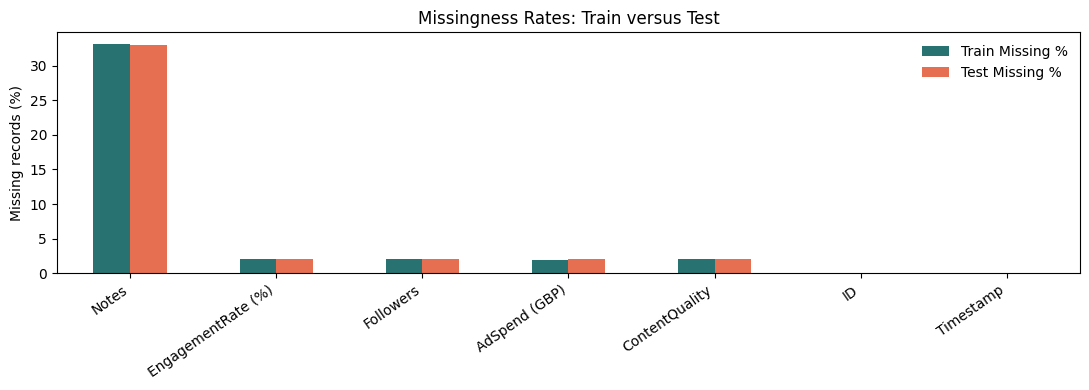

,Train Median,Test Median,Median Difference %,Train P05,Test P05,Train P95,Test P95
Variable,,,,,,,
followers,"100,000.000","99,586.000",-0.410,"50,121.050","51,522.000","149,312.500","149,964.200"
engagement_rate,2.800,2.800,0.130,0.730,0.730,4.790,4.800
ad_spend,"5,006.490","4,987.400",-0.380,"2,581.340","2,598.810","7,456.940","7,547.700"
content_quality,5.470,5.420,-0.960,1.450,1.450,9.560,9.520


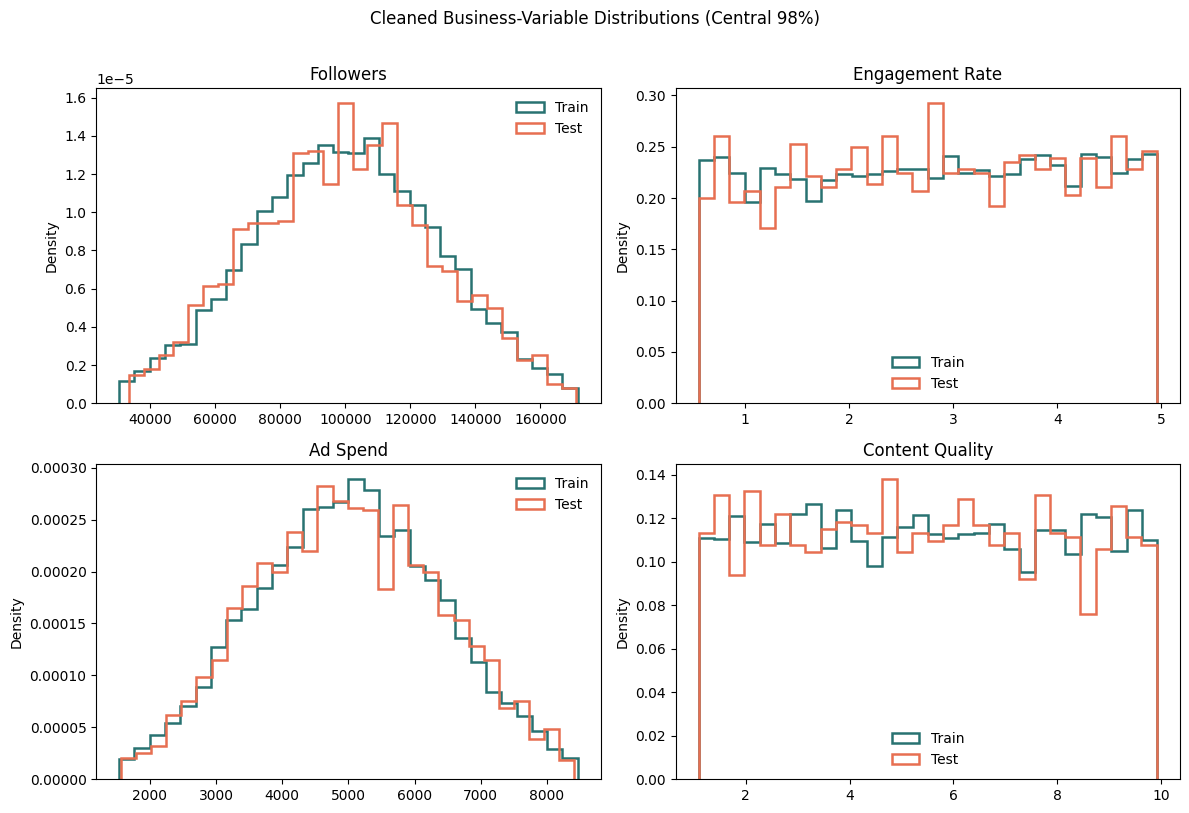

,Train Count,Train %,Test Count,Test %
followers_thousand_scaled_flag,200,2.500,200,10.000
followers_outlier_flag,5,0.062,5,0.250
engagement_invalid_flag,3,0.038,3,0.150
ad_spend_invalid_flag,3,0.038,3,0.150
ad_spend_outlier_flag,3,0.038,3,0.150
content_quality_invalid_flag,0,0.000,0,0.000


,Train,Test
Earliest Timestamp,2021-01-01 00:00:00,2021-01-01 00:00:00
Latest Timestamp,2023-09-27 00:00:00,2023-09-27 00:00:00
Missing Timestamp %,0.000,0.000


,Train %,Test %
Notes,,
Check,16.980,18.200
Good,16.180,17.500
Missing,33.150,33.000
Pending,17.090,16.250
Review,16.610,15.050


In [6]:
comparison_columns = [
    "Followers",
    "EngagementRate (%)",
    "AdSpend (GBP)",
    "ContentQuality",
    "ID",
    "Timestamp",
    "Notes",
]

missing_comparison = pd.DataFrame({
    "Train Missing Count": train[comparison_columns].isna().sum(),
    "Train Missing %": train[comparison_columns].isna().mean().mul(100),
    "Test Missing Count": test[comparison_columns].isna().sum(),
    "Test Missing %": test[comparison_columns].isna().mean().mul(100),
})
missing_comparison["Highest Missing %"] = missing_comparison[
    ["Train Missing %", "Test Missing %"]
].max(axis=1)
missing_comparison = (
    missing_comparison
    .sort_values("Highest Missing %", ascending=False)
    .drop(columns="Highest Missing %")
)
display(missing_comparison.round(2))

missing_comparison[["Train Missing %", "Test Missing %"]].plot(
    kind="bar",
    figsize=(11, 4),
    color=["#287271", "#e76f51"],
)
plt.title("Missingness Rates: Train versus Test")
plt.ylabel("Missing records (%)")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

quality_cleaner = CampaignCleaner()
train_quality_clean = quality_cleaner._basic_clean(train)
test_quality_clean = quality_cleaner._basic_clean(test)

business_variables = [
    "followers",
    "engagement_rate",
    "ad_spend",
    "content_quality",
]
distribution_rows = []
for column in business_variables:
    train_values = train_quality_clean[column].dropna()
    test_values = test_quality_clean[column].dropna()
    train_median = train_values.median()
    test_median = test_values.median()
    distribution_rows.append({
        "Variable": column,
        "Train Median": train_median,
        "Test Median": test_median,
        "Median Difference %": (
            100 * (test_median - train_median) / train_median
            if train_median != 0
            else np.nan
        ),
        "Train P05": train_values.quantile(0.05),
        "Test P05": test_values.quantile(0.05),
        "Train P95": train_values.quantile(0.95),
        "Test P95": test_values.quantile(0.95),
    })

distribution_comparison = pd.DataFrame(distribution_rows).set_index("Variable")
display(distribution_comparison.round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.ravel(), business_variables):
    combined = pd.concat(
        [train_quality_clean[column], test_quality_clean[column]]
    ).dropna()
    lower, upper = combined.quantile([0.01, 0.99])
    train_plot = train_quality_clean[column].between(lower, upper)
    test_plot = test_quality_clean[column].between(lower, upper)
    ax.hist(
        train_quality_clean.loc[train_plot, column],
        bins=30,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="#287271",
        label="Train",
    )
    ax.hist(
        test_quality_clean.loc[test_plot, column],
        bins=30,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="#e76f51",
        label="Test",
    )
    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

fig.suptitle("Cleaned Business-Variable Distributions (Central 98%)", y=1.01)
plt.tight_layout()
plt.show()

quality_flags = [
    "followers_thousand_scaled_flag",
    "followers_outlier_flag",
    "engagement_invalid_flag",
    "ad_spend_invalid_flag",
    "ad_spend_outlier_flag",
    "content_quality_invalid_flag",
]
quality_flag_comparison = pd.DataFrame({
    "Train Count": train_quality_clean[quality_flags].sum().astype(int),
    "Train %": train_quality_clean[quality_flags].mean().mul(100),
    "Test Count": test_quality_clean[quality_flags].sum().astype(int),
    "Test %": test_quality_clean[quality_flags].mean().mul(100),
})
display(quality_flag_comparison.round(3))

date_comparison = pd.DataFrame({
    "Train": {
        "Earliest Timestamp": pd.to_datetime(
            train["Timestamp"], errors="coerce"
        ).min(),
        "Latest Timestamp": pd.to_datetime(
            train["Timestamp"], errors="coerce"
        ).max(),
        "Missing Timestamp %": pd.to_datetime(
            train["Timestamp"], errors="coerce"
        ).isna().mean() * 100,
    },
    "Test": {
        "Earliest Timestamp": pd.to_datetime(
            test["Timestamp"], errors="coerce"
        ).min(),
        "Latest Timestamp": pd.to_datetime(
            test["Timestamp"], errors="coerce"
        ).max(),
        "Missing Timestamp %": pd.to_datetime(
            test["Timestamp"], errors="coerce"
        ).isna().mean() * 100,
    },
})
display(date_comparison)

notes_comparison = pd.concat(
    [
        train["Notes"].fillna("Missing").value_counts(normalize=True).mul(100)
        .rename("Train %"),
        test["Notes"].fillna("Missing").value_counts(normalize=True).mul(100)
        .rename("Test %"),
    ],
    axis=1,
).fillna(0)
display(notes_comparison.round(2).sort_index())

**Conclusion from the train-test audit:** Missingness rates, date coverage,
Notes categories, and the cleaned central distributions of followers, engagement,
ad spend, and content quality are broadly similar. The main shift is in formatting
and data quality: plain small follower values requiring the dataset assumption occur
in **2.5% of training rows (200/8,000)** but **10.0% of test rows (200/2,000)**.
The test set also has proportionally more follower outliers and invalid engagement
or spend values, although their absolute counts remain small. This is best described
as a **data-quality/format shift**, not evidence that the core campaign population
is materially different. It reinforces the need to apply the same fitted cleaning
pipeline to all future data.

### Follower-Scaling Evidence and Sensitivity

The raw follower values from 1 to 999 require special scrutiny because the source
does not provide an explicit unit indicator. The following audit shows how many
records are affected, whether they use a suffix, representative raw records, and
their distributions before and after the proposed multiplication by 1,000.

,dataset,rows,affected_records,affected_percentage,plain_numeric_affected,explicit_suffix_affected,raw_min,raw_q1,raw_median,raw_q3,raw_max,scaled_q1,scaled_median,scaled_q3
0,Train,8000,200,2.500,200,0,20.000,72.000,94.500,113.000,174.000,"72,000.000","94,500.000","113,000.000"
1,Test,2000,200,10.000,200,0,20.000,83.750,100.000,120.000,168.000,"83,750.000","100,000.000","120,000.000"


,group,median_followers
0,Affected training values - raw,94.500
1,Affected training values - scaled,"94,500.000"
2,Remaining training follower values,"100,097.500"


Representative affected training records across the sorted range:


,ID,Followers,Sales (Units),Timestamp
5736,646,20.000,3561,2022-05-17
3686,3856,58.000,8042,2022-02-17
4200,9524,72.000,7619,2021-11-19
7620,6966,82.000,7509,2021-03-23
4303,9774,90.000,4980,2021-10-16
7586,4249,98.000,11174,2021-06-19
4442,7064,107.000,8656,2021-01-02
1547,2298,119.000,10180,2023-09-17
2406,5899,132.000,8157,2022-05-05
7828,1291,174.000,16917,2022-10-09


Representative affected test records across the sorted range:


,ID,Followers,Timestamp
408,2884,20.000,2022-05-26
1016,921,69.000,2021-02-23
743,2602,80.000,2023-01-05
1308,3351,89.000,2021-01-26
9,439,98.000,2021-08-26
923,8384,103.000,2021-12-17
415,8864,114.000,2021-11-17
1072,8999,124.000,2021-01-10
1314,1441,135.000,2022-06-01
366,7414,168.000,2021-03-15


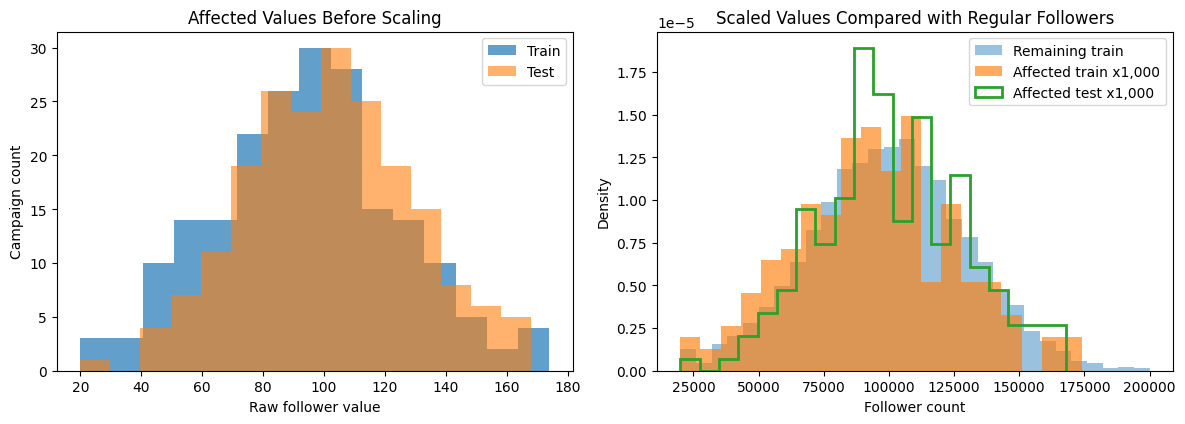

In [7]:
def follower_scaling_profile(df, dataset_name):
    raw = df["Followers"]
    raw_text = raw.astype("string").str.strip()
    parsed = raw.map(parse_messy_number)
    affected = parsed.between(1, 999, inclusive="both")
    explicit_suffix = raw_text.str.contains(r"[kKmMbB]\s*$", regex=True, na=False)
    affected_values = parsed[affected]

    return {
        "dataset": dataset_name,
        "rows": len(df),
        "affected_records": int(affected.sum()),
        "affected_percentage": float(affected.mean() * 100),
        "plain_numeric_affected": int((affected & ~explicit_suffix).sum()),
        "explicit_suffix_affected": int((affected & explicit_suffix).sum()),
        "raw_min": float(affected_values.min()),
        "raw_q1": float(affected_values.quantile(0.25)),
        "raw_median": float(affected_values.median()),
        "raw_q3": float(affected_values.quantile(0.75)),
        "raw_max": float(affected_values.max()),
        "scaled_q1": float((affected_values * 1000).quantile(0.25)),
        "scaled_median": float((affected_values * 1000).median()),
        "scaled_q3": float((affected_values * 1000).quantile(0.75)),
    }


follower_scaling_summary = pd.DataFrame([
    follower_scaling_profile(train, "Train"),
    follower_scaling_profile(test, "Test"),
])
display(follower_scaling_summary.round(2))

train_raw_followers = train["Followers"].map(parse_messy_number)
test_raw_followers = test["Followers"].map(parse_messy_number)
train_affected_mask = train_raw_followers.between(1, 999, inclusive="both")
test_affected_mask = test_raw_followers.between(1, 999, inclusive="both")

train_remaining_median = train_raw_followers[~train_affected_mask].median()
median_comparison = pd.DataFrame({
    "group": [
        "Affected training values - raw",
        "Affected training values - scaled",
        "Remaining training follower values",
    ],
    "median_followers": [
        train_raw_followers[train_affected_mask].median(),
        (train_raw_followers[train_affected_mask] * 1000).median(),
        train_remaining_median,
    ],
})
display(median_comparison.round(2))

def select_representative_follower_records(
    df,
    parsed_followers,
    affected_mask,
    display_columns,
    sample_size=10,
):
    affected_records = df.loc[affected_mask].copy()
    affected_records["_parsed_followers"] = parsed_followers.loc[
        affected_mask
    ]
    affected_records = affected_records.sort_values(
        "_parsed_followers"
    )
    positions = np.linspace(
        0,
        len(affected_records) - 1,
        min(sample_size, len(affected_records)),
    ).round().astype(int)
    return affected_records.iloc[positions][display_columns]


representative_train = select_representative_follower_records(
    train,
    train_raw_followers,
    train_affected_mask,
    ["ID", "Followers", "Sales (Units)", "Timestamp"],
)
representative_test = select_representative_follower_records(
    test,
    test_raw_followers,
    test_affected_mask,
    ["ID", "Followers", "Timestamp"],
)

print("Representative affected training records across the sorted range:")
display(representative_train)
print("Representative affected test records across the sorted range:")
display(representative_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(
    train_raw_followers[train_affected_mask],
    bins=15,
    alpha=0.7,
    label="Train",
)
axes[0].hist(
    test_raw_followers[test_affected_mask],
    bins=15,
    alpha=0.6,
    label="Test",
)
axes[0].set(
    title="Affected Values Before Scaling",
    xlabel="Raw follower value",
    ylabel="Campaign count",
)
axes[0].legend()

regular_train = train_raw_followers[
    ~train_affected_mask & train_raw_followers.between(0, 250_000)
]
axes[1].hist(
    regular_train,
    bins=30,
    density=True,
    alpha=0.45,
    label="Remaining train",
)
axes[1].hist(
    train_raw_followers[train_affected_mask] * 1000,
    bins=20,
    density=True,
    alpha=0.65,
    label="Affected train x1,000",
)
axes[1].hist(
    test_raw_followers[test_affected_mask] * 1000,
    bins=20,
    density=True,
    histtype="step",
    linewidth=2,
    label="Affected test x1,000",
)
axes[1].set(
    title="Scaled Values Compared with Regular Followers",
    xlabel="Follower count",
    ylabel="Density",
)
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
X_sensitivity = train[MODEL_FEATURES]
y_sensitivity = train["Sales (Units)"]

X_sens_dev, X_sens_random_holdout, y_sens_dev, y_sens_random_holdout = train_test_split(
    X_sensitivity,
    y_sensitivity,
    test_size=0.20,
    random_state=42,
)

sensitivity_dates = pd.to_datetime(train["Timestamp"], errors="coerce")
ordered_sensitivity_index = sensitivity_dates.sort_values(kind="stable").index
sensitivity_split_position = int(len(ordered_sensitivity_index) * 0.80)
sensitivity_cutoff = sensitivity_dates.loc[
    ordered_sensitivity_index[sensitivity_split_position]
]
sensitivity_development_index = sensitivity_dates[
    sensitivity_dates < sensitivity_cutoff
].index
sensitivity_temporal_index = sensitivity_dates[
    sensitivity_dates >= sensitivity_cutoff
].index

sensitivity_splits = {
    "Random holdout": (
        X_sens_dev,
        y_sens_dev,
        X_sens_random_holdout,
        y_sens_random_holdout,
    ),
    "Temporal holdout": (
        X_sensitivity.loc[sensitivity_development_index],
        y_sensitivity.loc[sensitivity_development_index],
        X_sensitivity.loc[sensitivity_temporal_index],
        y_sensitivity.loc[sensitivity_temporal_index],
    ),
}

sensitivity_rows = []
for validation_name, (X_fit, y_fit, X_score, y_score) in sensitivity_splits.items():
    for scaling_label, use_scaling in [
        ("Automatic x1,000", True),
        ("No automatic scaling", False),
    ]:
        sensitivity_model = make_model_pipeline(
            Ridge(alpha=30.0),
            scale_plain_small_followers=use_scaling,
        )
        sensitivity_model.fit(X_fit, y_fit)
        sensitivity_prediction = sensitivity_model.predict(X_score)
        sensitivity_rows.append({
            "validation": validation_name,
            "scaling_rule": scaling_label,
            **evaluate_predictions(y_score, sensitivity_prediction),
        })

follower_scaling_sensitivity = pd.DataFrame(sensitivity_rows)
print(
    "Temporal cutoff:",
    sensitivity_cutoff.date(),
    "| development rows:",
    len(sensitivity_development_index),
    "| holdout rows:",
    len(sensitivity_temporal_index),
)
display(follower_scaling_sensitivity.round(3))

sensitivity_pivot = follower_scaling_sensitivity.pivot(
    index="validation",
    columns="scaling_rule",
    values=["rmse", "r2"],
)
sensitivity_improvement = pd.DataFrame(
    index=sensitivity_pivot.index
)
sensitivity_improvement["RMSE - Automatic x1,000"] = (
    sensitivity_pivot[("rmse", "Automatic x1,000")]
)
sensitivity_improvement["RMSE - No automatic scaling"] = (
    sensitivity_pivot[("rmse", "No automatic scaling")]
)
sensitivity_improvement["RMSE Improvement"] = (
    sensitivity_pivot[("rmse", "No automatic scaling")]
    - sensitivity_pivot[("rmse", "Automatic x1,000")]
)
sensitivity_improvement["R2 - Automatic x1,000"] = (
    sensitivity_pivot[("r2", "Automatic x1,000")]
)
sensitivity_improvement["R2 - No automatic scaling"] = (
    sensitivity_pivot[("r2", "No automatic scaling")]
)
sensitivity_improvement["R2 Improvement"] = (
    sensitivity_pivot[("r2", "Automatic x1,000")]
    - sensitivity_pivot[("r2", "No automatic scaling")]
)

print("Direct improvement from the automatic x1,000 assumption:")
display(sensitivity_improvement.round(3))

Temporal cutoff: 2023-03-12 | development rows: 6400 | holdout rows: 1600


,validation,scaling_rule,rmse,mae,r2
0,Random holdout,"Automatic x1,000","2,042.365","1,633.182",0.475
1,Random holdout,No automatic scaling,"2,186.700","1,712.244",0.398
2,Temporal holdout,"Automatic x1,000","1,955.156","1,562.894",0.505
3,Temporal holdout,No automatic scaling,"2,110.503","1,660.518",0.423


Direct improvement from the automatic x1,000 assumption:


,"RMSE - Automatic x1,000",RMSE - No automatic scaling,RMSE Improvement,"R2 - Automatic x1,000",R2 - No automatic scaling,R2 Improvement
validation,,,,,,
Random holdout,"2,042.365","2,186.700",144.335,0.475,0.398,0.077
Temporal holdout,"1,955.156","2,110.503",155.346,0.505,0.423,0.082


#### Dataset Assumption - Follower-Unit Interpretation

The dataset contains 200 training records and 200 test records with plain numeric
follower values between 20 and 174, without an explicit `k` suffix. Interpreting
these values literally would produce follower counts substantially below the rest
of the dataset. Multiplying them by 1,000 produces a median of 94,500 followers
among the affected training records, close to the median of 100,098 among the
remaining training records.

The sensitivity comparison shows modest improvements under both random and
temporal validation when the scaling rule is applied. Therefore, these values are
interpreted as follower counts recorded in thousands. This remains a dataset
assumption and should be confirmed with the data owner before production
deployment.

### Conclusion - Step 4

The data has the expected messy-data characteristics: missing values, mixed numeric
formats, extreme outliers, a few invalid negative spend records, and a repeated set
of unusually small plain follower values. Train and test have similar missingness,
date coverage, Notes categories, and cleaned business-variable distributions, but
the test set contains more formatting and data-quality issues. Most notably, the
plain small-follower format occurs in 2.5% of training rows and 10.0% of test rows.

The follower-unit interpretation was tested above and is retained as a documented
dataset assumption rather than a confirmed business rule. Other
data-quality issues are handled inside the reusable transformer before modeling.

## Step 5 - Clean Data and Engineer Features

**Goal:** Apply the cleaner to inspect the model-ready feature set.

In [9]:
X = train[MODEL_FEATURES]
y = train["Sales (Units)"]

cleaner_preview = CampaignCleaner().fit(X)
clean_train = cleaner_preview.transform(X)
clean_train_with_target = clean_train.copy()
clean_train_with_target["Sales (Units)"] = y

print("Cleaned feature shape:", clean_train.shape)
display(clean_train.head())
display(clean_train_with_target[NUMERIC_FEATURES + ["Sales (Units)"]].describe().T)

Cleaned feature shape: (8000, 17)


,followers,engagement_rate,ad_spend,content_quality,log_followers,log_ad_spend,estimated_engaged_followers,log_estimated_engaged_followers,spend_per_1k_followers,quality_x_engagement,spend_x_quality,followers_thousand_scaled_flag,followers_outlier_flag,engagement_invalid_flag,ad_spend_invalid_flag,ad_spend_outlier_flag,content_quality_invalid_flag
0,"106,572.000",2.573,"2,614.378",5.276,11.577,7.869,"2,742.284",7.917,24.532,13.575,"13,792.623",0.000,0.000,0.000,0.000,0.000,0.000
1,"77,583.000",0.939,"4,975.963",8.756,11.259,8.513,728.891,6.593,64.137,8.226,"43,570.861",0.000,0.000,0.000,0.000,0.000,0.000
2,"92,832.000",2.176,"4,107.770",6.455,11.439,8.321,"2,020.118",7.611,44.249,14.046,"26,514.531",0.000,0.000,0.000,0.000,0.000,0.000
3,"53,565.000",1.478,"4,293.330",4.313,10.889,8.365,791.892,6.676,80.152,6.376,"18,516.331",0.000,0.000,0.000,0.000,0.000,0.000
4,"121,079.000",3.374,"5,343.549",3.769,11.704,8.584,"4,085.445",8.315,44.133,12.718,"20,140.087",0.000,0.000,0.000,0.000,0.000,0.000


,count,mean,std,min,25%,50%,75%,max
followers,"7,840.000","100,072.982","29,537.248","30,899.910","80,000.000","100,000.000","120,382.500","170,742.840"
engagement_rate,"7,837.000",2.780,1.304,0.554,1.650,2.799,3.909,4.958
ad_spend,"7,838.000","4,995.694","1,456.791","1,549.257","3,976.328","5,006.487","6,005.034","8,408.586"
content_quality,"7,840.000",5.493,2.607,1.089,3.227,5.469,7.780,9.922
log_followers,"7,840.000",11.464,0.332,10.339,11.290,11.513,11.698,12.048
log_ad_spend,"7,838.000",8.468,0.327,7.346,8.288,8.519,8.701,9.037
estimated_engaged_followers,"7,679.000","2,780.955","1,579.202",171.243,"1,476.498","2,611.216","3,870.200","8,465.291"
log_estimated_engaged_followers,"7,679.000",7.736,0.675,5.149,7.298,7.868,8.261,9.044
spend_per_1k_followers,"7,686.000",55.718,28.529,9.484,37.330,49.573,66.597,272.123
quality_x_engagement,"7,681.000",15.225,10.632,0.604,6.463,12.683,21.788,49.192


### Engineered Features

- `log_followers` and `log_ad_spend` reduce skew.
- `estimated_engaged_followers` combines audience size and engagement.
- `spend_per_1k_followers` measures cost relative to reach.
- `quality_x_engagement` captures the interaction between content quality and audience response.
- `spend_x_quality` captures the interaction between budget and creative quality.
- The observed campaign-end timestamp is reserved for chronological splitting and is not engineered into production-model inputs.
- Data-quality flags preserve information about messy records.

## Step 6 - Exploratory Data Analysis

**Goal:** Visualize important relationships before modeling.

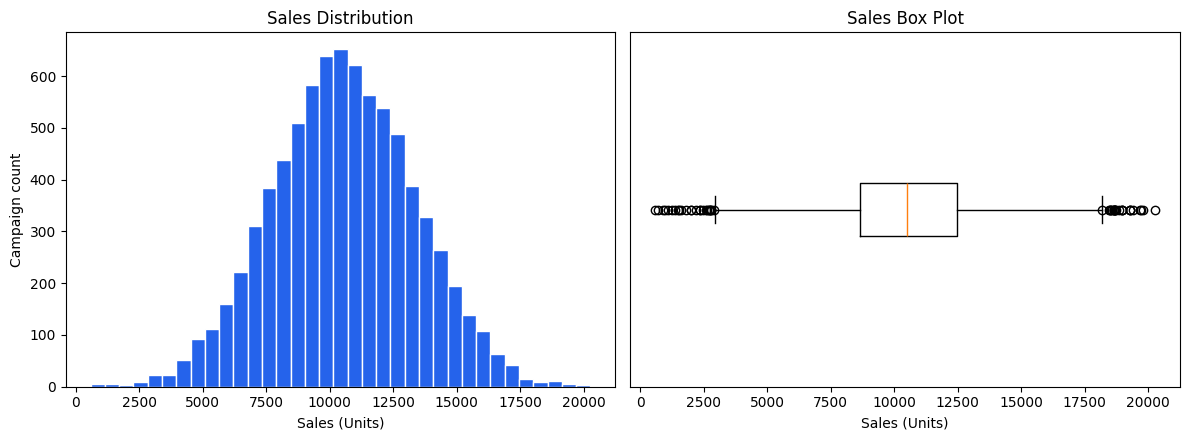

,quantile,sales_units
0,0.000,590.000
1,0.010,"4,073.950"
2,0.050,"5,968.000"
3,0.250,"8,642.250"
4,0.500,"10,500.000"
5,0.750,"12,459.000"
6,0.950,"15,189.450"
7,0.990,"16,934.390"
8,1.000,"20,263.000"


,target_q1,target_q3,iqr,lower_bound,upper_bound,low_outliers,high_outliers,total_outliers,percentage_of_train
0,"8,642.250","12,459.000","3,816.750","2,917.120","18,184.120",25,25,50,0.620


Lowest ten sales campaigns:


,ID,Sales (Units),Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Timestamp
0,2880,590,"32,853.000",0.6005522019483105,1924.7914361669705,1.856,2021-04-09
1,2266,693,"46,642.000",0.822427764041681,1000.0,8.221,2021-05-25
2,6944,879,"46,174.000",0.5934384037600744,£3731,1.697,2023-05-22
3,7813,960,"88,051.000",0.8953528294693154,NaN,1.699,2021-08-21
4,5901,1101,"24,331.000",2.7816959162151935,2862.8811359807296,1.373,2022-06-04
5,5321,1242,NaN,0.6480985862972266,1661.9330646414287,5.160,2021-03-02
6,5587,1372,"20,000.000",0.9450087799204264,5646.99827952957,1.793,2022-12-13
7,5387,1477,"54,624.000",3.503293810523634,1117.4612546728274,2.877,2021-04-01
8,1348,1535,"58,993.000",4.749197718449979,1658.3006639951273,5.555,2023-03-31
9,2023,1599,"60,735.000",1.3585651946412742,1470.820295171961,1.952,2023-03-08


Highest ten sales campaigns:


,ID,Sales (Units),Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Timestamp
0,4328,20263,"150,983.000",2.912253594471893,5165.161378634493,7.770,2022-12-11
1,5539,19789,"128,573.000",3.746612920421692,9705.029072483409,1.892,2023-02-26
2,5157,19718,"187,545.000",3.714185582698319,6667.064133483884,7.518,2023-01-31
3,7441,19657,"183,766.000",2.56286224306489,5496.279317394119,5.175,2023-05-16
4,7766,19398,"177,964.000",3.2416083966910008,7539.070149621876,9.629,2021-08-28
5,9592,19288,"137,570.000",4.321233815646293,£6483,6.030,2021-10-26
6,209,19286,"200,000.000",3.4983739540773153,5420.436937948861,3.033,2021-12-11
7,6766,19263,"164,067.000",2.548334201154725,7888.890980753392,2.846,2022-09-15
8,1035,18958,"147,219.000",2.7473205262111007,10000.0,8.971,2021-03-27
9,3384,18945,"133,177.000",3.311327569579061,7872.356757467607,4.280,2022-02-10


All 50 IQR-flagged target records are retained for modeling.


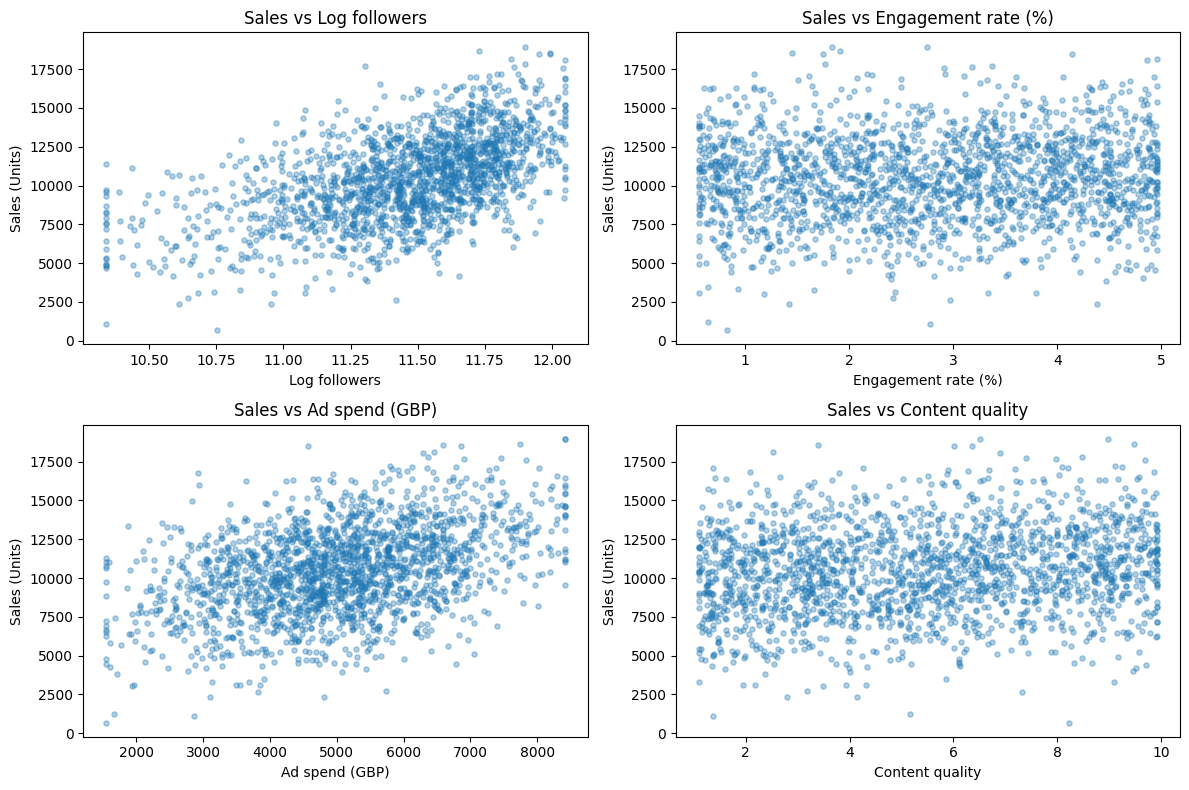

In [10]:
sales = train["Sales (Units)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sales, bins=35, edgecolor="white", color="#2563EB")
axes[0].set(
    title="Sales Distribution",
    xlabel="Sales (Units)",
    ylabel="Campaign count",
)
axes[1].boxplot(sales, vert=False)
axes[1].set(
    title="Sales Box Plot",
    xlabel="Sales (Units)",
    yticks=[],
)
plt.tight_layout()
plt.show()

sales_quantiles = (
    sales.quantile([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    .rename_axis("quantile")
    .reset_index(name="sales_units")
)
display(sales_quantiles.round(2))

target_q1 = sales.quantile(0.25)
target_q3 = sales.quantile(0.75)
target_iqr = target_q3 - target_q1
target_lower_bound = target_q1 - 1.5 * target_iqr
target_upper_bound = target_q3 + 1.5 * target_iqr
target_low_outlier_mask = sales < target_lower_bound
target_high_outlier_mask = sales > target_upper_bound
target_outlier_mask = target_low_outlier_mask | target_high_outlier_mask

target_outlier_summary = pd.DataFrame([
    {
        "target_q1": target_q1,
        "target_q3": target_q3,
        "iqr": target_iqr,
        "lower_bound": target_lower_bound,
        "upper_bound": target_upper_bound,
        "low_outliers": int(target_low_outlier_mask.sum()),
        "high_outliers": int(target_high_outlier_mask.sum()),
        "total_outliers": int(target_outlier_mask.sum()),
        "percentage_of_train": float(target_outlier_mask.mean() * 100),
    }
])
display(target_outlier_summary.round(2))

target_review_columns = [
    "ID",
    "Sales (Units)",
    "Followers",
    "EngagementRate (%)",
    "AdSpend (GBP)",
    "ContentQuality",
    "Timestamp",
]
print("Lowest ten sales campaigns:")
display(
    train.nsmallest(10, "Sales (Units)")[target_review_columns]
    .reset_index(drop=True)
)
print("Highest ten sales campaigns:")
display(
    train.nlargest(10, "Sales (Units)")[target_review_columns]
    .reset_index(drop=True)
)

print(
    "All",
    int(target_outlier_mask.sum()),
    "IQR-flagged target records are retained for modeling."
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
eda_sample = clean_train_with_target.sample(min(2000, len(clean_train_with_target)), random_state=42)

plot_specs = [
    ("log_followers", "Log followers"),
    ("engagement_rate", "Engagement rate (%)"),
    ("ad_spend", "Ad spend (GBP)"),
    ("content_quality", "Content quality"),
]

for ax, (column, label) in zip(axes.ravel(), plot_specs):
    ax.scatter(eda_sample[column], eda_sample["Sales (Units)"], alpha=0.35, s=14)
    ax.set_title(f"Sales vs {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Sales (Units)")

plt.tight_layout()
plt.show()

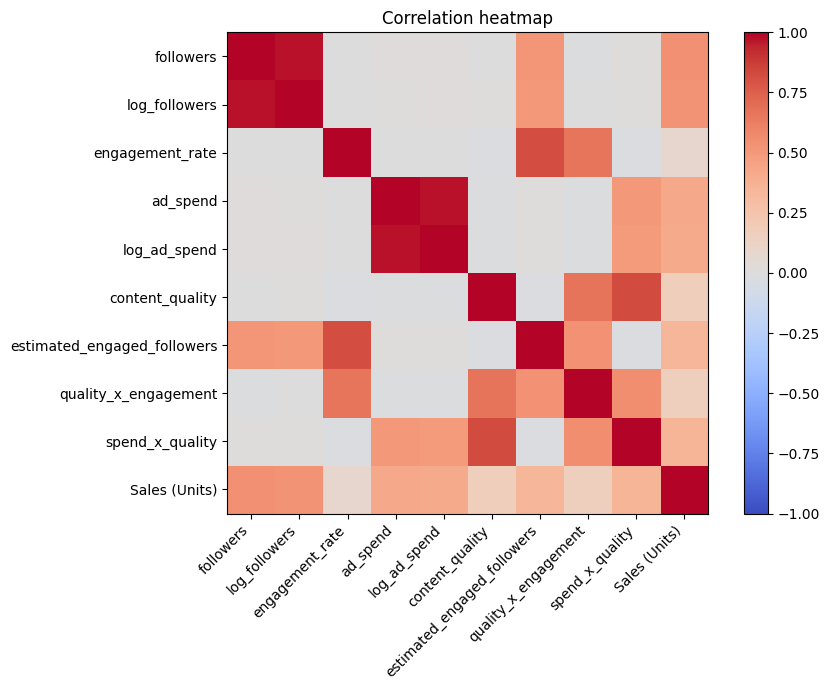

,correlation_with_sales
Sales (Units),1.000
followers,0.542
log_followers,0.530
ad_spend,0.419
log_ad_spend,0.412
spend_x_quality,0.351
estimated_engaged_followers,0.342
content_quality,0.169
quality_x_engagement,0.163
engagement_rate,0.078


In [11]:
corr_columns = [
    "followers",
    "log_followers",
    "engagement_rate",
    "ad_spend",
    "log_ad_spend",
    "content_quality",
    "estimated_engaged_followers",
    "quality_x_engagement",
    "spend_x_quality",
    "Sales (Units)",
]

corr = clean_train_with_target[corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticklabels(corr_columns)
ax.set_title("Correlation heatmap")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(corr["Sales (Units)"].sort_values(ascending=False).to_frame("correlation_with_sales"))

### Conclusion - Step 6

Sales range from 590 to 20,263 units. The IQR rule flags 50 campaigns: 25 below
2,917.12 units and 25 above 18,184.12 units. Statistical extremeness alone does not
establish a data error. The records remain in model training because the available
fields cannot determine whether they are genuine campaign outcomes, entry errors,
or campaigns from an unobserved business segment.

Historical sales show predictive associations with follower scale, ad spend, and
content quality. The engineered interaction terms allow the model to represent
combinations of reach, engagement, budget, and creative quality. These are
observational patterns and do not establish that changing any input will cause an
equivalent change in sales.

## Step 7 - Model Comparison with Random and Temporal Cross-Validation

In [12]:
# Random validation estimates performance on campaigns similar to the training mix.
X_random_dev, X_random_holdout, y_random_dev, y_random_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)
random_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Temporal validation simulates training on history and predicting later campaigns.
campaign_dates = pd.to_datetime(train["Timestamp"], errors="coerce")
ordered_index = campaign_dates.sort_values(kind="stable").index
temporal_split_position = int(len(ordered_index) * 0.80)
temporal_cutoff = campaign_dates.loc[ordered_index[temporal_split_position]]
temporal_dev_index = ordered_index[
    campaign_dates.loc[ordered_index] < temporal_cutoff
]
temporal_holdout_index = ordered_index[
    campaign_dates.loc[ordered_index] >= temporal_cutoff
]

X_temporal_dev = X.loc[temporal_dev_index]
y_temporal_dev = y.loc[temporal_dev_index]
X_temporal_holdout = X.loc[temporal_holdout_index]
y_temporal_holdout = y.loc[temporal_holdout_index]

# One campaign date contains eight rows; the gap avoids adjacent folds sharing a date.
temporal_cv = TimeSeriesSplit(n_splits=5, gap=8)

split_summary = pd.DataFrame([
    {
        "validation": "Random",
        "development_rows": len(X_random_dev),
        "holdout_rows": len(X_random_holdout),
        "development_start": campaign_dates.loc[X_random_dev.index].min().date(),
        "development_end": campaign_dates.loc[X_random_dev.index].max().date(),
        "holdout_start": campaign_dates.loc[X_random_holdout.index].min().date(),
        "holdout_end": campaign_dates.loc[X_random_holdout.index].max().date(),
    },
    {
        "validation": "Temporal",
        "development_rows": len(X_temporal_dev),
        "holdout_rows": len(X_temporal_holdout),
        "development_start": campaign_dates.loc[X_temporal_dev.index].min().date(),
        "development_end": campaign_dates.loc[X_temporal_dev.index].max().date(),
        "holdout_start": campaign_dates.loc[X_temporal_holdout.index].min().date(),
        "holdout_end": campaign_dates.loc[X_temporal_holdout.index].max().date(),
    },
])
print("Validation split design:")
display(split_summary)

candidate_models = {
    "Baseline mean": make_model_pipeline(
        DummyRegressor(strategy="mean")
    ),
    "Linear regression": make_model_pipeline(
        LinearRegression()
    ),
    "Ridge regression": make_model_pipeline(
        Ridge(alpha=30.0)
    ),
    "Lasso regression": make_model_pipeline(
        Lasso(alpha=10.0, max_iter=20_000)
    ),
    "Elastic Net": make_model_pipeline(
        ElasticNet(
            alpha=0.03,
            l1_ratio=0.9,
            max_iter=20_000,
        )
    ),
    "Gradient boosting": make_model_pipeline(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            random_state=42,
        )
    ),
    "Random forest": make_model_pipeline(
        RandomForestRegressor(
            n_estimators=120,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=1,
        )
    ),
    "Extra Trees": make_model_pipeline(
        ExtraTreesRegressor(
            n_estimators=120,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=1,
        )
    ),
    "Histogram gradient boosting": make_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.04,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=42,
        )
    ),
}

validation_setups = {
    "Random KFold": (X_random_dev, y_random_dev, random_cv),
    "Temporal TimeSeriesSplit": (
        X_temporal_dev,
        y_temporal_dev,
        temporal_cv,
    ),
}

cv_rows = []
for validation_name, (X_cv, y_cv, cv_strategy) in validation_setups.items():
    for model_name, pipeline in candidate_models.items():
        scores = cross_validate(
            pipeline,
            X_cv,
            y_cv,
            cv=cv_strategy,
            scoring={
                "rmse": "neg_root_mean_squared_error",
                "mae": "neg_mean_absolute_error",
                "r2": "r2",
            },
            n_jobs=1,
        )
        cv_rows.append({
            "validation": validation_name,
            "model": model_name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
        })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["validation", "cv_rmse_mean"]
)
display(cv_results)

# Test whether the engineered representation improves deployment-aligned CV.
cleaned_raw_numeric_features = PRODUCTION_NUMERIC_FEATURES
feature_ablation_rows = []
for feature_set, numeric_features in [
    ("Cleaned raw features", cleaned_raw_numeric_features),
    ("Raw + engineered features", NUMERIC_FEATURES),
]:
    feature_scores = cross_validate(
        make_model_pipeline(
            Lasso(alpha=10.0, max_iter=20_000),
            numeric_features=numeric_features,
        ),
        X_temporal_dev,
        y_temporal_dev,
        cv=temporal_cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
    )
    feature_ablation_rows.append({
        "Feature set": feature_set,
        "Temporal CV RMSE": -feature_scores["test_rmse"].mean(),
        "Temporal CV R²": feature_scores["test_r2"].mean(),
    })

feature_engineering_ablation = pd.DataFrame(feature_ablation_rows)
print("Feature-engineering ablation:")
display(feature_engineering_ablation.round(3))

# Availability ablations use the deployment-aligned temporal folds.
X_temporal_dev_with_notes = train.loc[
    X_temporal_dev.index,
    MODEL_FEATURES + ["Notes"],
]
notes_ablation_rows = []
for notes_label, notes_features, include_notes in [
    ("Notes excluded", X_temporal_dev, False),
    ("Notes included", X_temporal_dev_with_notes, True),
]:
    notes_scores = cross_validate(
        make_model_pipeline(
            Lasso(alpha=10.0, max_iter=20_000),
            include_notes=include_notes,
        ),
        notes_features,
        y_temporal_dev,
        cv=temporal_cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=1,
    )
    notes_ablation_rows.append({
        "notes_treatment": notes_label,
        "cv_rmse_mean": -notes_scores["test_rmse"].mean(),
        "cv_mae_mean": -notes_scores["test_mae"].mean(),
        "cv_r2_mean": notes_scores["test_r2"].mean(),
    })

notes_ablation_results = pd.DataFrame(notes_ablation_rows)
print("Notes availability and leakage sensitivity:")
display(notes_ablation_results.round(3))

X_temporal_dev_with_timestamp = train.loc[
    X_temporal_dev.index,
    MODEL_FEATURES + ["Timestamp"],
]
timestamp_ablation_rows = []
for timestamp_label, timestamp_features, include_timestamp in [
    ("Timestamp excluded", X_temporal_dev, False),
    ("Timestamp included", X_temporal_dev_with_timestamp, True),
]:
    timestamp_scores = cross_validate(
        make_model_pipeline(
            Lasso(alpha=10.0, max_iter=20_000),
            include_timestamp=include_timestamp,
        ),
        timestamp_features,
        y_temporal_dev,
        cv=temporal_cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=1,
    )
    timestamp_ablation_rows.append({
        "timestamp_treatment": timestamp_label,
        "cv_rmse_mean": -timestamp_scores["test_rmse"].mean(),
        "cv_mae_mean": -timestamp_scores["test_mae"].mean(),
        "cv_r2_mean": timestamp_scores["test_r2"].mean(),
    })

timestamp_ablation_results = pd.DataFrame(timestamp_ablation_rows)
print("Campaign-end timestamp availability sensitivity:")
display(timestamp_ablation_results.round(3))

Validation split design:


,validation,development_rows,holdout_rows,development_start,development_end,holdout_start,holdout_end
0,Random,6400,1600,2021-01-01,2023-09-27,2021-01-01,2023-09-27
1,Temporal,6400,1600,2021-01-01,2023-03-11,2023-03-12,2023-09-27


,validation,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,cv_r2_std
1,Random KFold,Linear regression,"1,996.080",25.887,"1,588.384",0.493,0.017
4,Random KFold,Elastic Net,"1,996.083",25.801,"1,588.388",0.493,0.017
2,Random KFold,Ridge regression,"1,996.102",25.720,"1,588.399",0.493,0.017
3,Random KFold,Lasso regression,"1,996.176",25.714,"1,588.504",0.493,0.017
5,Random KFold,Gradient boosting,"2,020.610",19.606,"1,609.142",0.480,0.015
7,Random KFold,Extra Trees,"2,061.430",20.408,"1,645.387",0.459,0.011
8,Random KFold,Histogram gradient boosting,"2,083.351",16.332,"1,667.239",0.448,0.014
6,Random KFold,Random forest,"2,084.478",20.998,"1,664.079",0.447,0.010
0,Random KFold,Baseline mean,"2,805.803",15.324,"2,243.974",-0.002,0.002
11,Temporal TimeSeriesSplit,Ridge regression,"2,035.096",39.847,"1,621.764",0.474,0.037


Feature-engineering ablation:


,Feature set,Temporal CV RMSE,Temporal CV R²
0,Cleaned raw features,"2,035.246",0.474
1,Raw + engineered features,"2,035.081",0.475


Notes availability and leakage sensitivity:


,notes_treatment,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,Notes excluded,"2,035.246","1,622.105",0.474
1,Notes included,"2,035.697","1,622.508",0.474


Campaign-end timestamp availability sensitivity:


,timestamp_treatment,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,Timestamp excluded,"2,035.246","1,622.105",0.474
1,Timestamp included,"2,035.577","1,623.267",0.474


### Conclusion - Step 7

The random track estimates performance on campaigns drawn from a similar date mix,
while the temporal track trains only on earlier campaigns and validates on later
ones. The expanding-window `TimeSeriesSplit` includes an eight-row gap so adjacent
folds do not share the same campaign-end date.

Under the tested configurations, regularized linear models performed better than
the evaluated tree ensembles. This suggests that the cleaned representation is
adequately captured by a largely linear model, but it does not prove that the
underlying business relationship is additive.

The feature-engineering ablation is a practical tie: engineered features improve
temporal CV RMSE by only 0.165 units against an RMSE above 2,000. The production
pipeline therefore uses only the four cleaned campaign variables. Engineered
features remain in the notebook as an experiment and for exploratory
interpretation, not because they provide meaningful predictive improvement.

The deployment-aligned temporal ablations also confirm that excluding `Notes` and
the observed campaign-end `Timestamp` does not reduce predictive accuracy.


## Step 8 - Hyperparameter Tuning with Matched Validation Strategies

In [13]:
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0]
}
lasso_param_grid = {
    "model__alpha": [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
}
elastic_net_param_grid = {
    "model__alpha": [0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    "model__l1_ratio": [0.5, 0.9],
}
hgb_param_distributions = {
    "model__learning_rate": [0.02, 0.04, 0.07, 0.10],
    "model__max_iter": [200, 400, 700],
    "model__max_leaf_nodes": [7, 15, 31, 63],
    "model__min_samples_leaf": [10, 20, 40, 80],
    "model__l2_regularization": [0.0, 0.1, 1.0, 10.0],
}


def tune_candidate_models(X_fit, y_fit, cv_strategy):
    searches = {
        "Tuned Ridge regression": GridSearchCV(
            make_model_pipeline(Ridge()),
            param_grid=ridge_param_grid,
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            refit=True,
        ),
        "Tuned Lasso regression": GridSearchCV(
            make_model_pipeline(Lasso(max_iter=20_000)),
            param_grid=lasso_param_grid,
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            refit=True,
        ),
        "Tuned Elastic Net": GridSearchCV(
            make_model_pipeline(ElasticNet(max_iter=20_000)),
            param_grid=elastic_net_param_grid,
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            refit=True,
        ),
        "Tuned histogram gradient boosting": RandomizedSearchCV(
            make_model_pipeline(
                HistGradientBoostingRegressor(random_state=42)
            ),
            param_distributions=hgb_param_distributions,
            n_iter=20,
            random_state=42,
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            refit=True,
        ),
    }
    for search in searches.values():
        search.fit(X_fit, y_fit)
    return searches


random_searches = tune_candidate_models(
    X_random_dev,
    y_random_dev,
    random_cv,
)
temporal_searches = tune_candidate_models(
    X_temporal_dev,
    y_temporal_dev,
    temporal_cv,
)

tuned_rows = []
for validation_name, searches in [
    ("Random KFold", random_searches),
    ("Temporal TimeSeriesSplit", temporal_searches),
]:
    for model_name, search in searches.items():
        tuned_rows.append({
            "validation": validation_name,
            "model": model_name,
            "best_cv_rmse": -search.best_score_,
            "best_params": search.best_params_,
        })

tuned_results = pd.DataFrame(tuned_rows).sort_values(
    ["validation", "best_cv_rmse"]
)
random_best_search = max(
    random_searches.values(),
    key=lambda search: search.best_score_,
)
temporal_best_search = max(
    temporal_searches.values(),
    key=lambda search: search.best_score_,
)

# The temporal search defines the deployment model because the use case predicts
# campaigns occurring after the available historical data.
best_model = temporal_best_search.best_estimator_

display(tuned_results)
print(
    "Random-track selected model:",
    type(random_best_search.best_estimator_.named_steps["model"]).__name__,
)
print("Random-track selected parameters:", random_best_search.best_params_)
print(
    "Temporal-track selected model:",
    type(temporal_best_search.best_estimator_.named_steps["model"]).__name__,
)
print("Temporal-track selected parameters:", temporal_best_search.best_params_)

,validation,model,best_cv_rmse,best_params
2,Random KFold,Tuned Elastic Net,"1,996.079","{'model__alpha': 0.01, 'model__l1_ratio': 0.9}"
0,Random KFold,Tuned Ridge regression,"1,996.079",{'model__alpha': 3.0}
1,Random KFold,Tuned Lasso regression,"1,996.080",{'model__alpha': 0.1}
3,Random KFold,Tuned histogram gradient boosting,"2,026.249","{'model__min_samples_leaf': 10, 'model__max_le..."
5,Temporal TimeSeriesSplit,Tuned Lasso regression,"2,034.470",{'model__alpha': 30.0}
4,Temporal TimeSeriesSplit,Tuned Ridge regression,"2,035.001",{'model__alpha': 100.0}
6,Temporal TimeSeriesSplit,Tuned Elastic Net,"2,035.470","{'model__alpha': 0.3, 'model__l1_ratio': 0.9}"
7,Temporal TimeSeriesSplit,Tuned histogram gradient boosting,"2,077.703","{'model__min_samples_leaf': 10, 'model__max_le..."


Random-track selected model: ElasticNet
Random-track selected parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Temporal-track selected model: Lasso
Temporal-track selected parameters: {'model__alpha': 30.0}


### Conclusion - Step 8

Ridge, Lasso, and Elastic Net use focused regularization grids. Histogram gradient
boosting uses a reproducible 20-configuration randomized search across learning
rate, maximum iterations, maximum leaf nodes, minimum samples per leaf, and L2
regularization.

Each candidate uses the validation strategy associated with its holdout: shuffled
five-fold CV for the random track and expanding-window `TimeSeriesSplit` for the
temporal track. Model selection is based on the lowest temporal CV RMSE. Lasso is
selected by a narrow margin, while Ridge remains effectively tied within
cross-validation variability.

## Step 9 - Random and Temporal Holdout Evaluation

,validation,rmse,mae,r2
0,Random holdout,"2,042.313","1,633.233",0.475
1,Temporal holdout,"1,956.462","1,563.634",0.504


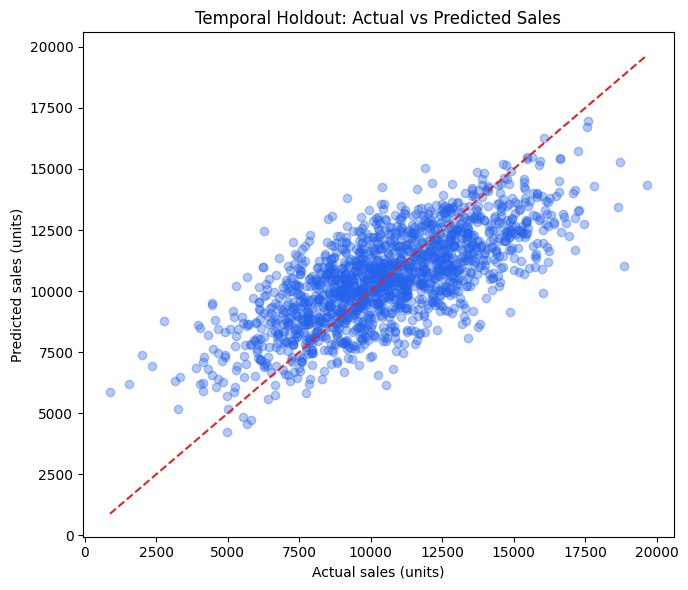

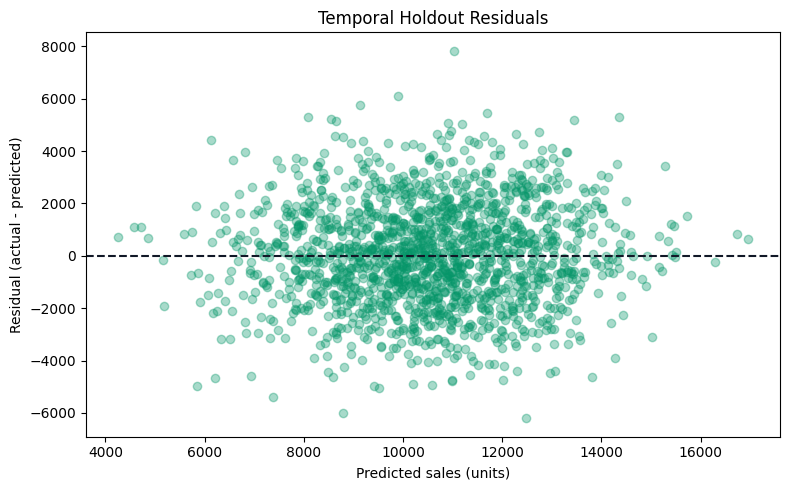

In [14]:
random_evaluation_model = clone(
    random_best_search.best_estimator_
)
random_evaluation_model.fit(X_random_dev, y_random_dev)
random_holdout_pred = random_evaluation_model.predict(X_random_holdout)

temporal_evaluation_model = clone(
    temporal_best_search.best_estimator_
)
temporal_evaluation_model.fit(X_temporal_dev, y_temporal_dev)
temporal_holdout_pred = temporal_evaluation_model.predict(
    X_temporal_holdout
)

holdout_results = pd.DataFrame([
    {
        "validation": "Random holdout",
        **evaluate_predictions(y_random_holdout, random_holdout_pred),
    },
    {
        "validation": "Temporal holdout",
        **evaluate_predictions(
            y_temporal_holdout,
            temporal_holdout_pred,
        ),
    },
])
display(holdout_results.round(3))

# Downstream diagnostics use the deployment-aligned temporal holdout.
best_model = temporal_evaluation_model
X_holdout = X_temporal_holdout
y_holdout = y_temporal_holdout
holdout_pred = temporal_holdout_pred

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_holdout, holdout_pred, alpha=0.35, color="#2563EB")
line_min = min(y_holdout.min(), holdout_pred.min())
line_max = max(y_holdout.max(), holdout_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], color="#DC2626", linestyle="--")
ax.set(
    title="Temporal Holdout: Actual vs Predicted Sales",
    xlabel="Actual sales (units)",
    ylabel="Predicted sales (units)",
)
plt.tight_layout()
plt.show()

residuals = y_holdout.to_numpy() - holdout_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(holdout_pred, residuals, alpha=0.35, color="#059669")
ax.axhline(0, color="#111827", linestyle="--")
ax.set(
    title="Temporal Holdout Residuals",
    xlabel="Predicted sales (units)",
    ylabel="Residual (actual - predicted)",
)
plt.tight_layout()
plt.show()

### Stakeholder-Friendly Holdout Evaluation

RMSE, MAE, and R² remain the primary technical metrics, but the measures below
translate model error into campaign-planning terms. Each baseline predicts the
mean sales from its own development period, so holdout outcomes do not leak into
the comparison. Positive bias means average overprediction; negative bias means
average underprediction.

,Average Actual Sales,MAE % of Average Sales,Median Absolute Error,Within ±10%,Within ±20%,Average Prediction Bias
Random holdout,"10,475.230",15.590,"1,426.200",38.560,69.060,72.660
Temporal holdout,"10,582.660",14.780,"1,319.760",40.060,71.810,-51.070


,Model RMSE,Mean-Baseline RMSE,RMSE Reduction vs Baseline %
Random holdout,"2,042.310","2,820.180",27.580
Temporal holdout,"1,956.460","2,778.860",29.590


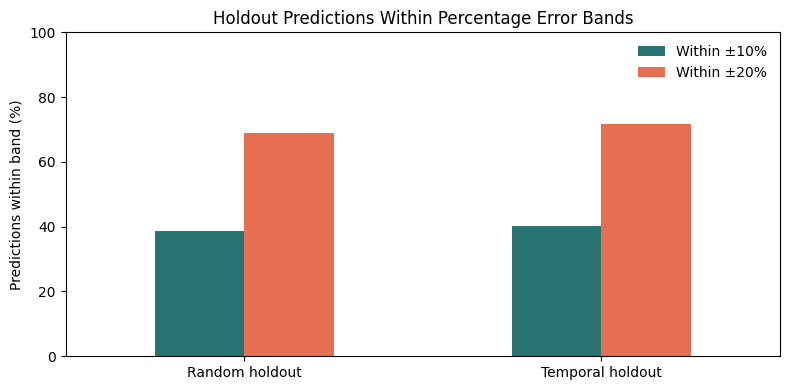

Business interpretation: 69% of random-holdout predictions are within ±20% of actual sales, and RMSE is 28% lower than the mean baseline.


In [15]:
def stakeholder_evaluation(y_true, y_pred, development_target):
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    absolute_error = np.abs(actual - predicted)
    percentage_error = absolute_error / np.maximum(np.abs(actual), 1.0)

    model_rmse = np.sqrt(mean_squared_error(actual, predicted))
    baseline_prediction = np.full(
        actual.shape,
        float(np.mean(development_target)),
        dtype=float,
    )
    baseline_rmse = np.sqrt(
        mean_squared_error(actual, baseline_prediction)
    )

    return {
        "Average Actual Sales": float(np.mean(actual)),
        "MAE % of Average Sales": (
            100 * float(np.mean(absolute_error)) / float(np.mean(actual))
        ),
        "Median Absolute Error": float(np.median(absolute_error)),
        "Within ±10%": 100 * float(np.mean(percentage_error <= 0.10)),
        "Within ±20%": 100 * float(np.mean(percentage_error <= 0.20)),
        "Average Prediction Bias": float(np.mean(predicted - actual)),
        "Model RMSE": float(model_rmse),
        "Mean-Baseline RMSE": float(baseline_rmse),
        "RMSE Reduction vs Baseline %": (
            100 * (baseline_rmse - model_rmse) / baseline_rmse
        ),
    }


stakeholder_results = pd.DataFrame({
    "Random holdout": stakeholder_evaluation(
        y_random_holdout,
        random_holdout_pred,
        y_random_dev,
    ),
    "Temporal holdout": stakeholder_evaluation(
        y_temporal_holdout,
        temporal_holdout_pred,
        y_temporal_dev,
    ),
}).T

display(
    stakeholder_results[[
        "Average Actual Sales",
        "MAE % of Average Sales",
        "Median Absolute Error",
        "Within ±10%",
        "Within ±20%",
        "Average Prediction Bias",
    ]].round(2)
)
display(
    stakeholder_results[[
        "Model RMSE",
        "Mean-Baseline RMSE",
        "RMSE Reduction vs Baseline %",
    ]].round(2)
)

stakeholder_results[["Within ±10%", "Within ±20%"]].plot(
    kind="bar",
    figsize=(8, 4),
    color=["#287271", "#e76f51"],
)
plt.title("Holdout Predictions Within Percentage Error Bands")
plt.ylabel("Predictions within band (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

random_business_metrics = stakeholder_results.loc["Random holdout"]
print(
    "Business interpretation: "
    f"{random_business_metrics['Within ±20%']:.0f}% of random-holdout "
    "predictions are within ±20% of actual sales, and RMSE is "
    f"{random_business_metrics['RMSE Reduction vs Baseline %']:.0f}% lower "
    "than the mean baseline."
)

**Business interpretation:** Approximately **69% of random-holdout
predictions are within ±20% of actual sales**, and RMSE improves by approximately
**28% over the mean baseline**. This is more intuitive for campaign teams than R²
alone. The temporal results remain the more realistic estimate for future campaigns,
while average bias reveals whether forecasts systematically over- or under-predict.

### Target-Outlier Residual Analysis

To evaluate all 50 extreme-sales campaigns without fitting and scoring the same
rows, the selected temporal model configuration is assessed using five-fold
out-of-fold predictions across the complete training set. This residual diagnostic
uses shuffled folds only to obtain predictions for every row; temporal holdout
performance remains the primary deployment metric.

,segment,rows,rmse,mae,prediction_bias
0,Non-outlier campaigns,7950,"1,974.100","1,577.950",-0.300
1,All IQR target outliers,50,"4,899.690","4,716.820",96.730
2,Low target outliers,25,"4,999.860","4,813.560","4,813.560"
3,High target outliers,25,"4,797.440","4,620.090","-4,620.090"


Largest residual errors among IQR target outliers:


,ID,Sales (Units),Followers,AdSpend (GBP),ContentQuality,OOF Predicted Sales,Residual,Absolute Error
6599,7813,960,"88,051.000",NaN,1.699,8992,-8032,8032
3605,6160,18861,"104,302.000",NaN,NaN,11011,7850,7850
3096,4106,2631,"91,172.000",3825.585381091424,7.311,9565,-6934,6934
1942,4328,20263,"150,983.000",5165.161378634493,7.770,13631,6632,6632
7023,3030,2463,"25,350.000",6837.472112083827,8.269,9049,-6586,6586
1612,7054,2690,104.000,3241.567771392992,4.362,9181,-6491,6491
811,5321,1242,NaN,1661.9330646414287,5.160,7553,-6311,6311
7324,7239,2778,"70,092.000",£4526,5.333,8754,-5976,5976
21,6874,2577,"59,582.000",4413.004392156703,9.585,8521,-5944,5944
5165,3830,18944,NaN,8522.027762980813,6.505,13204,5740,5740


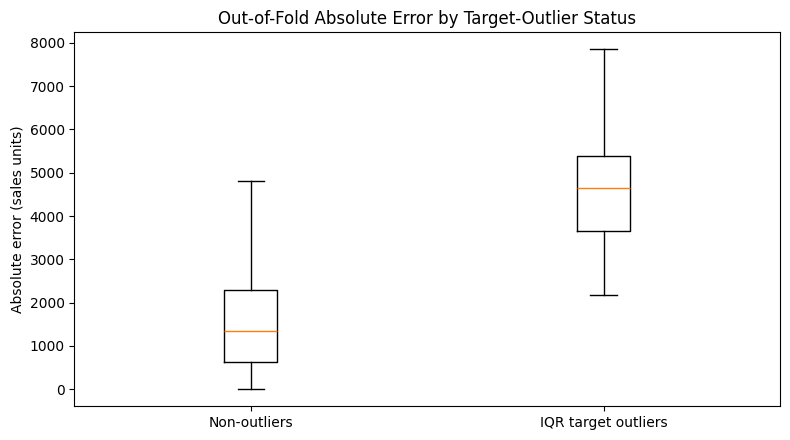

In [16]:
target_diagnostic_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)
target_oof_prediction = cross_val_predict(
    clone(temporal_best_search.best_estimator_),
    X,
    y,
    cv=target_diagnostic_cv,
    n_jobs=1,
)
target_oof_residual = y.to_numpy() - target_oof_prediction
target_oof_absolute_error = np.abs(target_oof_residual)

target_segment_rows = []
target_segments = {
    "Non-outlier campaigns": ~target_outlier_mask,
    "All IQR target outliers": target_outlier_mask,
    "Low target outliers": target_low_outlier_mask,
    "High target outliers": target_high_outlier_mask,
}
for segment_name, segment_mask in target_segments.items():
    segment_array = segment_mask.to_numpy()
    segment_actual = y.to_numpy()[segment_array]
    segment_prediction = target_oof_prediction[segment_array]
    target_segment_rows.append({
        "segment": segment_name,
        "rows": int(segment_array.sum()),
        "rmse": float(
            np.sqrt(mean_squared_error(segment_actual, segment_prediction))
        ),
        "mae": float(mean_absolute_error(segment_actual, segment_prediction)),
        "prediction_bias": float(
            (segment_prediction - segment_actual).mean()
        ),
    })

target_residual_summary = pd.DataFrame(target_segment_rows)
display(target_residual_summary.round(2))

target_residual_review = train.loc[
    target_outlier_mask,
    ["ID", "Sales (Units)", "Followers", "AdSpend (GBP)", "ContentQuality"],
].copy()
target_residual_review["OOF Predicted Sales"] = np.rint(
    target_oof_prediction[target_outlier_mask.to_numpy()]
).astype(int)
target_residual_review["Residual"] = np.rint(
    target_oof_residual[target_outlier_mask.to_numpy()]
).astype(int)
target_residual_review["Absolute Error"] = np.rint(
    target_oof_absolute_error[target_outlier_mask.to_numpy()]
).astype(int)

print("Largest residual errors among IQR target outliers:")
display(
    target_residual_review.sort_values(
        "Absolute Error",
        ascending=False,
    ).head(10)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(
    [
        target_oof_absolute_error[(~target_outlier_mask).to_numpy()],
        target_oof_absolute_error[target_outlier_mask.to_numpy()],
    ],
    tick_labels=["Non-outliers", "IQR target outliers"],
    showfliers=False,
)
ax.set(
    title="Out-of-Fold Absolute Error by Target-Outlier Status",
    ylabel="Absolute error (sales units)",
)
plt.tight_layout()
plt.show()

#### Target-Outlier Decision

Extreme campaigns have materially larger prediction errors, with the model tending
to overpredict unusually low sales and underpredict unusually high sales. This is
an important model limitation, not sufficient evidence for deleting the records.
All 50 campaigns remain in training. They should be removed only if the data owner
confirms entry errors or identifies a separate population requiring its own model.

### Segment-Level Out-of-Fold Error Analysis

The same out-of-fold predictions are segmented below to reveal where aggregate
metrics hide weaker performance. Each campaign is assigned to exactly one segment
within every dimension, and every table reports its record count. Follower and
spend bands are descriptive quantile groups from the training data. Results for
very small segments should be treated as directional rather than precise.

This shuffled out-of-fold analysis provides broad coverage across years and
campaign types; the chronological holdout remains the primary deployment estimate.

In [17]:
def make_quantile_segments(series, quantiles, labels, missing_label):
    segments = pd.Series(
        missing_label,
        index=series.index,
        dtype=object,
    )
    valid_mask = series.notna()
    segments.loc[valid_mask] = (
        pd.qcut(
            series.loc[valid_mask],
            q=quantiles,
            labels=labels,
            duplicates="drop",
        )
        .astype(object)
    )
    return segments


def segment_error_summary(dimension, segment_values, segment_order):
    actual = y.to_numpy(dtype=float)
    predicted = np.asarray(target_oof_prediction, dtype=float)
    rows = []

    for segment_name in segment_order:
        mask = segment_values.eq(segment_name).to_numpy()
        count = int(mask.sum())
        if count == 0:
            metrics = {
                "RMSE": np.nan,
                "MAE": np.nan,
                "Prediction Bias": np.nan,
                "Within ±20%": np.nan,
            }
        else:
            segment_actual = actual[mask]
            segment_prediction = predicted[mask]
            percentage_error = (
                np.abs(segment_actual - segment_prediction)
                / np.maximum(np.abs(segment_actual), 1.0)
            )
            metrics = {
                "RMSE": float(np.sqrt(mean_squared_error(
                    segment_actual,
                    segment_prediction,
                ))),
                "MAE": float(mean_absolute_error(
                    segment_actual,
                    segment_prediction,
                )),
                "Prediction Bias": float(
                    np.mean(segment_prediction - segment_actual)
                ),
                "Within ±20%": 100 * float(
                    np.mean(percentage_error <= 0.20)
                ),
            }
        rows.append({
            "Dimension": dimension,
            "Segment": segment_name,
            "Records": count,
            **metrics,
        })
    return pd.DataFrame(rows)


segment_clean = CampaignCleaner()._basic_clean(train)

follower_order = [
    "Low followers",
    "Medium followers",
    "High followers",
    "Missing/invalid followers",
]
follower_segments = make_quantile_segments(
    segment_clean["followers"],
    quantiles=3,
    labels=follower_order[:3],
    missing_label=follower_order[3],
)

spend_order = [
    "Q1 lowest spend",
    "Q2 lower-middle spend",
    "Q3 upper-middle spend",
    "Q4 highest spend",
    "Missing/invalid spend",
]
spend_segments = make_quantile_segments(
    segment_clean["ad_spend"],
    quantiles=4,
    labels=spend_order[:4],
    missing_label=spend_order[4],
)

parsed_core_columns = [
    "followers",
    "engagement_rate",
    "ad_spend",
    "content_quality",
]
missing_core_order = [
    "No missing/invalid parsed core inputs",
    "At least one missing/invalid parsed core input",
]
missing_core_mask = (
    segment_clean[parsed_core_columns]
    .isna()
    .any(axis=1)
)
missing_core_segments = pd.Series(
    np.where(
        missing_core_mask,
        missing_core_order[1],
        missing_core_order[0],
    ),
    index=train.index,
)

invalid_flag_columns = [
    "followers_outlier_flag",
    "engagement_invalid_flag",
    "ad_spend_invalid_flag",
    "ad_spend_outlier_flag",
    "content_quality_invalid_flag",
]
invalid_order = [
    "No invalid/outlier flags",
    "At least one invalid/outlier flag",
]
invalid_segments = pd.Series(
    np.where(
        segment_clean[invalid_flag_columns].any(axis=1),
        invalid_order[1],
        invalid_order[0],
    ),
    index=train.index,
)

scaled_order = [
    "Follower scaling not applied",
    "Follower scaling applied",
]
scaled_segments = pd.Series(
    np.where(
        segment_clean["followers_thousand_scaled_flag"].eq(1),
        scaled_order[1],
        scaled_order[0],
    ),
    index=train.index,
)

parsed_year = pd.to_datetime(train["Timestamp"], errors="coerce").dt.year
year_segments = parsed_year.map(
    lambda value: (
        "Missing timestamp"
        if pd.isna(value)
        else str(int(value))
    )
)
year_order = sorted(
    value for value in year_segments.unique()
    if value != "Missing timestamp"
)
if year_segments.eq("Missing timestamp").any():
    year_order.append("Missing timestamp")

segment_definitions = [
    ("Follower band", follower_segments, follower_order),
    ("Ad-spend quartile", spend_segments, spend_order),
    ("Missing core inputs", missing_core_segments, missing_core_order),
    ("Invalid/outlier status", invalid_segments, invalid_order),
    ("Follower scaling status", scaled_segments, scaled_order),
    ("Campaign year", year_segments, year_order),
]

segment_error_results = pd.concat(
    [
        segment_error_summary(dimension, values, order)
        for dimension, values, order in segment_definitions
    ],
    ignore_index=True,
)

segment_count_check = segment_error_results.groupby(
    "Dimension"
)["Records"].sum()
assert segment_count_check.eq(len(train)).all(), (
    "Every segment dimension must account for all training records."
)
display(segment_count_check.rename("Records represented").to_frame())

for dimension, _, _ in segment_definitions:
    print(dimension)
    display(
        segment_error_results.loc[
            segment_error_results["Dimension"].eq(dimension),
            [
                "Segment",
                "Records",
                "RMSE",
                "MAE",
                "Prediction Bias",
                "Within ±20%",
            ],
        ]
        .set_index("Segment")
        .round(2)
    )

minimum_reliable_segment_size = 30
small_segment_warning = segment_error_results.loc[
    segment_error_results["Records"] < minimum_reliable_segment_size,
    ["Dimension", "Segment", "Records"],
]
if not small_segment_warning.empty:
    print(
        "Caution: the following segments contain fewer than "
        f"{minimum_reliable_segment_size} records:"
    )
    display(small_segment_warning)

,Records represented
Dimension,
Ad-spend quartile,8000
Campaign year,8000
Follower band,8000
Follower scaling status,8000
Invalid/outlier status,8000
Missing core inputs,8000


Follower band


,Records,RMSE,MAE,Prediction Bias,Within ±20%
Segment,,,,,
Low followers,2614,"2,008.190","1,597.160",16.810,62.390
Medium followers,2612,"1,980.720","1,577.100",39.720,71.670
High followers,2614,"1,984.250","1,586.040",-49.840,78.230
Missing/invalid followers,160,"2,623.120","2,126.920",-93.460,58.750


Ad-spend quartile


,Records,RMSE,MAE,Prediction Bias,Within ±20%
Segment,,,,,
Q1 lowest spend,1960,"1,962.650","1,558.430",35.610,65.150
Q2 lower-middle spend,1959,"1,954.820","1,563.840",-35.510,69.370
Q3 upper-middle spend,1959,"2,024.830","1,620.900",12.050,72.230
Q4 highest spend,1960,"2,028.240","1,617.230",-43.050,76.330
Missing/invalid spend,162,"2,547.720","1,959.190",388.990,58.640


...

,Records,RMSE,MAE,Prediction Bias,Within ±20%
Segment,,,,,
Follower scaling not applied,7800,"2,004.430","1,595.960",-5.900,70.620
Follower scaling applied,200,"2,054.020","1,660.240",242.480,67.000


Campaign year


,Records,RMSE,MAE,Prediction Bias,Within ±20%
Segment,,,,,
2021,2975,"2,002.390","1,586.130",-63.900,71.060
2022,2862,"2,009.120","1,608.170",84.990,69.950
2023,2163,"2,005.670","1,599.280",-23.420,70.550


Caution: the following segments contain fewer than 30 records:


,Dimension,Segment,Records
12,Invalid/outlier status,At least one invalid/outlier flag,14


**How to use this diagnostic:** Compare both error magnitude and the
percentage within ±20%, while checking `Records` before drawing conclusions.
Differences identify reliability gaps and monitoring priorities; they do not prove
that segment membership causes the error. Small invalid/outlier groups are
especially uncertain and should be monitored as more campaigns become available.

### Prediction-Interval Calibration and Independent Validation

The interval radius is calibrated using only the final chronological portion of
the temporal development data. Coverage is then measured once on the untouched
latest-20% temporal holdout, so the reported coverage is not guaranteed by the
quantile used to construct the interval.


In [18]:
# Reserve the latest 20% of temporal development rows for interval calibration.
calibration_cutoff_position = int(len(temporal_dev_index) * 0.80)
calibration_cutoff_date = campaign_dates.loc[
    temporal_dev_index[calibration_cutoff_position]
]
interval_training_index = temporal_dev_index[
    campaign_dates.loc[temporal_dev_index] < calibration_cutoff_date
]
interval_calibration_index = temporal_dev_index[
    campaign_dates.loc[temporal_dev_index] >= calibration_cutoff_date
]

interval_calibration_model = clone(
    temporal_best_search.best_estimator_
)
interval_calibration_model.fit(
    X.loc[interval_training_index],
    y.loc[interval_training_index],
)
interval_calibration_pred = interval_calibration_model.predict(
    X.loc[interval_calibration_index]
)
interval_calibration_error = np.abs(
    y.loc[interval_calibration_index].to_numpy()
    - interval_calibration_pred
)
prediction_interval_half_width_90 = float(
    np.quantile(interval_calibration_error, 0.90)
)
prediction_interval_radius_units = int(
    np.rint(prediction_interval_half_width_90)
)

temporal_interval_lower = np.maximum(
    temporal_holdout_pred - prediction_interval_half_width_90,
    0,
)
temporal_interval_upper = (
    temporal_holdout_pred + prediction_interval_half_width_90
)
temporal_interval_coverage = float(np.mean(
    (y_temporal_holdout.to_numpy() >= temporal_interval_lower)
    & (y_temporal_holdout.to_numpy() <= temporal_interval_upper)
))
average_interval_width = float(np.mean(
    temporal_interval_upper - temporal_interval_lower
))

prediction_interval_summary = pd.DataFrame({
    "Calibration records": [len(interval_calibration_index)],
    "Interval radius (units)": [prediction_interval_radius_units],
    "Temporal-holdout coverage": [f"{temporal_interval_coverage:.1%}"],
    "Average interval width (units)": [average_interval_width],
    "Target coverage": ["90%"],
})
display(prediction_interval_summary.round(1))


,Calibration records,Interval radius (units),Temporal-holdout coverage,Average interval width (units),Target coverage
0,1288,3252,90.9%,"6,504.300",90%


The temporal-holdout coverage is an independent diagnostic rather than a
by-construction result. This remains an **approximate residual-based interval**,
not a formal guarantee for every campaign. It uses one global radius and assumes
future errors resemble the calibration period; coverage may deteriorate under
distribution shift or for difficult segments. The lower bound is clipped at zero
because negative unit sales are not meaningful.


### Conclusion - Step 9

The random holdout measures general performance on a mixed-date sample. The
temporal holdout is the more realistic deployment test because every scored
campaign occurs after the development period. Reporting both makes any performance
change over time visible rather than hiding it inside a shuffled split.

Stakeholder metrics supplement RMSE, MAE, and R² with median error, MAE relative
to average sales, percentage-error bands, prediction bias, and improvement over a
development-only mean baseline. Approximately 69% of random-holdout predictions
fall within ±20% of actual sales, while RMSE is approximately 28% lower than the
mean baseline.

Segment-level out-of-fold diagnostics compare follower bands,
spend quartiles, missing inputs, invalid/outlier flags, follower scaling, and
campaign years. Every table includes its sample size, and each dimension accounts
for all 8,000 training campaigns. Small groups are treated as directional evidence.

A global approximate 90% prediction interval is calibrated on a held-out
chronological subset of temporal development data and its coverage is evaluated
on the untouched temporal holdout. This communicates forecast uncertainty but is
not a formal guarantee for every campaign or segment.

Downstream residual diagnostics and feature importance use the temporal holdout.
Some error remains because the dataset omits product type, discounting,
creator-audience fit, competitor activity, inventory constraints, and other potentially relevant
predictors.

The target-outlier diagnostic shows substantially larger errors for the 50
IQR-flagged campaigns. These records are retained, and the limitation is reported
rather than hidden through automatic target trimming.

## Step 10 - Feature Importance and Business Insights

**Goal:** Understand which campaign attributes influence predictions the most.

,feature,importance_mean,importance_std
0,Followers,0.575,0.028
2,AdSpend (GBP),0.317,0.008
3,ContentQuality,0.054,0.006
1,EngagementRate (%),0.010,0.003


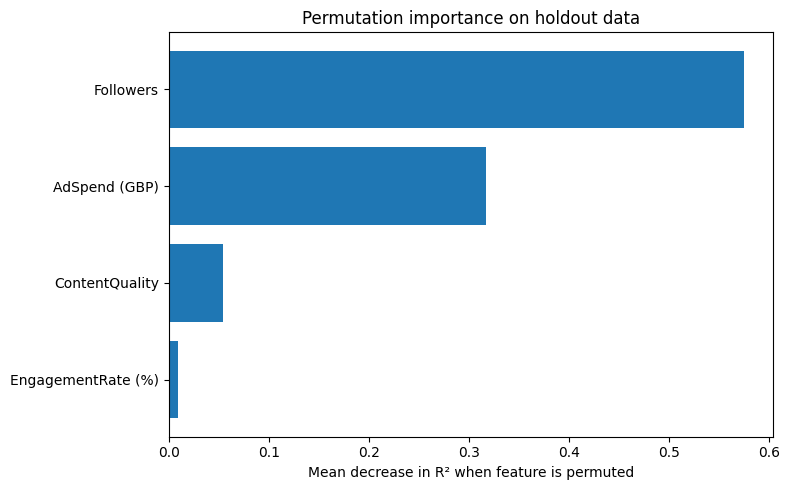

In [19]:
importance_result = permutation_importance(
    best_model,
    X_holdout,
    y_holdout,
    n_repeats=8,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

feature_importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("importance_mean", ascending=False)

display(feature_importance)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = feature_importance.sort_values("importance_mean").tail(8)
ax.barh(plot_data["feature"], plot_data["importance_mean"])
ax.set_title("Permutation importance on holdout data")
ax.set_xlabel("Mean decrease in R² when feature is permuted")
plt.tight_layout()
plt.show()

### Interpreting Permutation Importance

The final production model uses only the four cleaned campaign variables.
Permutation importance therefore measures the predictive contribution of each
raw business input after parsing, validity checks, clipping, imputation, and
scaling. It no longer bundles log transforms or interaction features into a
feature-family score.

Correlated inputs can still distribute or mask permutation importance. These
results measure predictive association in this historical dataset; they do not
estimate causal effects.


### Business Insights

1. **Followers and ad spend are the strongest predictive inputs in this historical dataset.**
2. **Content quality has a smaller predictive association**, in the cleaned raw-feature model.
3. **Engagement contributes predictive information** as a cleaned raw input.
4. **This observational analysis does not establish that changing these factors will cause an equivalent change in sales.**
5. **The observed campaign-end Timestamp and Notes are excluded** because they may be unavailable before prediction and add no validation benefit.

### Marketing Recommendation

Use model predictions as a planning estimate, then combine them with commercial
judgment such as margin, creator fit, product availability, brand risk, and
prediction uncertainty before committing campaign budget.

## Step 11 - Train Final Model and Predict on Test Data

**Goal:** Fit the selected model on all available training data and predict sales for the separate test dataset.

In [20]:
final_model = clone(best_model)
final_model.fit(X, y)

test_predictions = final_model.predict(test[MODEL_FEATURES]).clip(min=0).round().astype(int)

submission = test[["ID"]].copy()
submission["Predicted Sales (Units)"] = test_predictions

display(submission.head())
display(submission["Predicted Sales (Units)"].describe().to_frame("summary"))

submission.to_csv(PREDICTIONS_PATH, index=False)
print("Prediction file created:", PREDICTIONS_PATH.name)

,ID,Predicted Sales (Units)
0,6252,12600
1,4684,8955
2,1731,10190
3,4742,10900
4,4521,11676


,summary
count,"2,000.000"
mean,"10,532.299"
std,"1,926.159"
min,"4,748.000"
25%,"9,211.250"
50%,"10,525.500"
75%,"11,806.500"
max,"16,681.000"


Prediction file created: messy_test_predictions.csv


### Conclusion - Step 11

The model generated predictions for every row in the messy test dataset. The final training step uses all available labeled data before scoring the separate test file.

## Step 12 - Reusable Future Prediction Function

**Goal:** Provide a simple function that can score future messy campaign data.

In [21]:
def predict_sales_for_campaigns(
    new_campaign_data,
    fitted_model=final_model,
    interval_radius_units=prediction_interval_radius_units,
):
    """Predict sales, uncertainty, and input-quality warnings."""
    missing_columns = [
        column
        for column in MODEL_FEATURES
        if column not in new_campaign_data.columns
    ]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    model_inputs = new_campaign_data[MODEL_FEATURES]
    parsed_inputs = CampaignCleaner()._basic_clean(model_inputs)
    raw_to_parsed = {
        "Followers": "followers",
        "EngagementRate (%)": "engagement_rate",
        "AdSpend (GBP)": "ad_spend",
        "ContentQuality": "content_quality",
    }
    warning_messages = []
    imputed_fields = []
    reliability_flags = []

    for row_position, row_index in enumerate(model_inputs.index):
        row_warnings = []
        row_imputed_fields = []
        for raw_column, parsed_column in raw_to_parsed.items():
            raw_value = model_inputs.loc[row_index, raw_column]
            parsed_value = parse_messy_number(raw_value)
            cleaned_value = parsed_inputs.loc[row_index, parsed_column]
            if pd.isna(raw_value):
                reason = "was missing"
            elif pd.isna(parsed_value):
                reason = "could not be parsed"
            elif pd.isna(cleaned_value):
                reason = "was outside the accepted range"
            else:
                continue
            row_warnings.append(
                f"{raw_column} {reason} and was imputed"
            )
            row_imputed_fields.append(raw_column)

        if row_warnings:
            warning_messages.append(
                "Warning: " + "; ".join(row_warnings) + "."
            )
            imputed_fields.append(", ".join(row_imputed_fields))
            reliability_flags.append("Review - imputed input")
        else:
            warning_messages.append("None")
            imputed_fields.append("None")
            reliability_flags.append("Standard")

    point_prediction = (
        fitted_model.predict(model_inputs)
        .clip(min=0)
        .round()
        .astype(int)
    )
    lower_bound = np.maximum(
        point_prediction - interval_radius_units,
        0,
    ).astype(int)
    upper_bound = (
        point_prediction + interval_radius_units
    ).astype(int)

    output = new_campaign_data.copy()
    output["Input Warning"] = warning_messages
    output["Imputed Fields"] = imputed_fields
    output["Prediction Reliability Flag"] = reliability_flags
    output["Predicted Sales (Units)"] = point_prediction
    output["Approx. 90% Lower (Units)"] = lower_bound
    output["Approx. 90% Upper (Units)"] = upper_bound
    return output


future_example = pd.DataFrame([
    {
        "Followers": "125k",
        "EngagementRate (%)": "3.2%",
        "AdSpend (GBP)": "GBP 5,000",
        "ContentQuality": 8,
    }
])

future_prediction = predict_sales_for_campaigns(future_example)
display(future_prediction)

example_result = future_prediction.iloc[0]
print(
    f"Expected sales: "
    f"{int(example_result['Predicted Sales (Units)']):,} units"
)
print(
    "Approximate 90% range: "
    f"{int(example_result['Approx. 90% Lower (Units)']):,}-"
    f"{int(example_result['Approx. 90% Upper (Units)']):,} units"
)

invalid_future_example = future_example.copy()
invalid_future_example["AdSpend (GBP)"] = "wrong value"
invalid_future_prediction = predict_sales_for_campaigns(
    invalid_future_example
)
print("Invalid-input validation example:")
display(invalid_future_prediction[[
    "Input Warning",
    "Imputed Fields",
    "Prediction Reliability Flag",
]])


,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Input Warning,Imputed Fields,Prediction Reliability Flag,Predicted Sales (Units),Approx. 90% Lower (Units),Approx. 90% Upper (Units)
0,125k,3.2%,"GBP 5,000",8,None,None,Standard,12306,9054,15558


Expected sales: 12,306 units
Approximate 90% range: 9,054-15,558 units
Invalid-input validation example:


,Input Warning,Imputed Fields,Prediction Reliability Flag
0,Warning: AdSpend (GBP) could not be parsed and...,AdSpend (GBP),Review - imputed input


### Conclusion - Step 12

The prediction function handles future messy records with shorthand followers,
percent strings, and currency-formatted spend. It now reports any missing,
unparseable, or out-of-range core input that the pipeline imputes, lists the
affected fields, and marks the prediction for review. This prevents silent
imputation from creating false confidence.

The observed campaign-end `Timestamp`, `Notes`, and `ID` are deliberately not
required. Each result includes a point estimate and an approximate 90% range
calibrated on temporal development data and independently checked on the temporal
holdout.


## Final Conclusion

This case study satisfies the requested approach:

- Cleaned messy campaign data.
- Explored and visualized sales relationships.
- Tested log transforms, interactions, and data-quality flags, then selected the equally accurate simpler raw-feature pipeline.
- Trained regression models.
- Used cross-validation and hyperparameter tuning.
- Evaluated performance using RMSE, MAE, R², percentage-error bands, bias, and baseline improvement.
- Evaluated errors across campaign segments with record counts.
- Explained the strongest predictive inputs without making causal claims.
- Added temporally calibrated prediction ranges and independently evaluated their coverage.
- Built a reusable prediction function for future messy campaign data.

The deployment-aligned temporal track selected Lasso with `α = 30` by a narrow
cross-validation margin over Ridge. It achieved an RMSE of 1,956 units, MAE of
1,564 units, and R² of 0.504 on the latest-20% temporal holdout. The separately
selected random-track Elastic Net achieved RMSE of 2,042 units, MAE of 1,633
units, and R² of 0.475 on the random holdout. Approximately 69% of random-holdout
predictions and 72% of temporal-holdout
predictions were within ±20% of actual sales.

The solution is submission-friendly because all code and explanation are contained in this single notebook. It can be exported directly as one PDF without depending on a separate Python file.